
# Shinkansen Travel Experience Project

**About:**
This problem statement is based on the Shinkansen Bullet Train in Japan, and passengers’ experience with that mode of travel. This machine-learning exercise aims to determine the relative importance of each parameter with regard to their contribution to the passengers’ overall travel experience. The dataset contains a random sample of individuals who travelled on this train. The on-time performance of the trains along with passenger information is published in a file named ‘Traveldata_train.csv’.  These passengers were later asked to provide their feedback on various parameters related to the travel, along with their overall experience. These collected details are made available in the survey report labelled ‘Surveydata_train.csv’.

In the survey, each passenger was explicitly asked whether they were satisfied with their overall travel experience or not, and that is captured in the data of the survey report under the variable labelled ‘Overall_Experience’.

The objective of this problem is to understand which parameters play an important role in swaying passenger feedback towards a positive scale. You are provided test data containing the travel data and the survey data of passengers. Both the test data and the train data are collected at the same time and belong to the same population.       

**Goal:**
The goal of the problem is to predict whether a passenger was satisfied or not, considering his/her overall experience of traveling on the Shinkansen Bullet Train.

**Dataset:**
The problem consists of 2 separate datasets: Travel data & Survey data. Travel data has information related to passengers and attributes related to the Shinkansen train, in which they traveled. The survey data is aggregated data of surveys indicating the post-service experience. You are expected to treat both these datasets as raw data and perform any necessary data cleaning/validation steps as required.

The data has been split into two groups and provided in the Dataset folder. The folder contains both train and test data separately.

Train_Data
Test_Data

**Target Variable:**
Overall_Experience (1 represents ‘satisfied’, and 0 represents ‘not satisfied’)

The training set can be used to build your machine-learning model. The training set has labels for the target column - Overall_Experience.

The testing set should be used to see how well your model performs on unseen data. For the test set, it is expected to predict the ‘Overall_Experience’ level for each participant.

**Data Dictionary:**
All the data is self-explanatory. The survey levels are explained in the Data Dictionary file.

**Submission File Format:** You will need to submit a CSV file with exactly 35,602 entries plus a header row. The file should have exactly two columns

ID
Overall_Experience (contains 0 & 1 values, 1 represents ‘Satisfied’, and 0 represents ‘Not Satisfied’)

Evaluation Criteria: **bold text**

Accuracy Score: The evaluation metric is simply the percentage of predictions made by the model that turned out to be correct. This is also called the accuracy of the model. It will be calculated as the total number of correct predictions (True Positives + True Negatives) divided by the total number of observations in the dataset.

In other words, the best possible accuracy is 100% (or 1), and the worst possible accuracy is 0%

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# Setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get different metric scores
import sklearn.metrics as metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

In [4]:
# Load Travel and Survey data for train and test
travel_train = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/Traveldata_train_(1).csv")
survey_train = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/Surveydata_train_(1).csv")
travel_test  = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/Traveldata_test_(1).csv")
survey_test  = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/Surveydata_test_(1).csv")

# Merge Travel and Survey datasets on ID
train = travel_train.merge(survey_train, on='ID', how='inner')
test  = travel_test.merge(survey_test,   on='ID', how='inner')

# Copy to avoid changes to merged data
data       = train.copy()
test_data  = test.copy()

In [5]:
data.head()

,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,Female,Loyal Customer,52.00000,NaN,Business,272,0.00000,5.00000,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,Male,Loyal Customer,48.00000,Personal Travel,Eco,2200,9.00000,0.00000,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,Female,Loyal Customer,43.00000,Business Travel,Business,1061,77.00000,119.00000,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,Female,Loyal Customer,44.00000,Business Travel,Business,780,13.00000,18.00000,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,Female,Loyal Customer,50.00000,Business Travel,Business,1981,0.00000,0.00000,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


Observations:
all 25 columns are there — 9 from Travel data and 16 from Survey data joined correctly on ID.
A couple of things already visible from just head():

Row 0 has a NaN in Type_Travel — confirms the missing values we saw earlier
Row 3 has a NaN in Catering — same
The survey rating columns are text (e.g. "Needs Improvement", "Excellent") — confirms we'll need that ordinal encoding step later
Overall_Experience is already 0/1 which is good

In [6]:
data.tail()

,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
94374,98894375,Male,Loyal Customer,32.00000,Business Travel,Business,1357,83.00000,125.00000,0,Poor,Ordinary,Good,Good,Convenient,Poor,Poor,Poor,Poor,Good,Good,Good,Needs Improvement,Good,Poor
94375,98894376,Male,Loyal Customer,44.00000,Business Travel,Business,592,5.00000,11.00000,1,Good,Ordinary,Good,Good,Convenient,Needs Improvement,Excellent,Excellent,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Good
94376,98894377,Male,NaN,63.00000,Business Travel,Business,2794,0.00000,0.00000,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Acceptable,Good,Acceptable
94377,98894378,Male,Loyal Customer,16.00000,Personal Travel,Eco,2744,0.00000,0.00000,0,Needs Improvement,Ordinary,NaN,Needs Improvement,Convenient,Good,Needs Improvement,Good,Good,Acceptable,Good,Good,Good,Excellent,Good
94378,98894379,Male,Loyal Customer,54.00000,NaN,Eco,2107,28.00000,28.00000,0,Acceptable,Ordinary,Poor,Acceptable,Manageable,Acceptable,Acceptable,Acceptable,Acceptable,Poor,Good,Good,Poor,Good,Acceptable


Observations: Consistent with head() — same 25 columns, and you can see more missing values scattered in the last rows (row 94376 has NaN in Customer_Type, row 94377 has NaN in Arrival_Time_Convenient, row 94378 has NaN in Type_Travel). Confirms the missing values are spread throughout the dataset, not clustered at one end.
Also confirms the dataset has 94,379 rows (index goes 0 to 94378).

In [7]:
data.shape

(94379, 25)

Observations: exactly what we expected. 94,379 rows and 25 columns — 9 from Travel + 16 from Survey, merged cleanly on ID.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
 9   Overall_Experience       94379 non-null  int64  
 10  Seat_Comfort             94318 non-null  object 
 11  Seat_Class               94379 non-null  object 
 12  Arrival_Time_Convenient  85449 non-null  object 
 13  Catering                 85638 non-null  object 
 14  Platform_Location     

Observations:
Missing values confirmed — three columns have significant missings:

Customer_Type — 8,951 missing
Type_Travel — 9,226 missing
Arrival_Time_Convenient — 8,930 missing
Catering — 8,741 missing
Onboard_Service — 7,601 missing

The rest have only minor missings (under ~400).
Data types look correct:

Overall_Experience is already int64 (0/1) — good, no conversion needed
Travel_Distance is int64 — fine
Age, Departure_Delay_in_Mins, Arrival_Delay_in_Mins are float64 due to the missing values
All 19 object columns are the categorical/text columns we'll encode later

No issues with the merge — ID column is fully populated (94,379 non-null).

In [9]:
data.duplicated().sum()

np.int64(0)

No duplicates — clean dataset

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,94379.00000,98847190.00000,27245.01487,98800001.00000,98823595.50000,98847190.00000,98870784.50000,98894379.00000
Age,94346.00000,39.41965,15.11663,7.00000,27.00000,40.00000,51.00000,85.00000
Travel_Distance,94379.00000,1978.88818,1027.96102,50.00000,1359.00000,1923.00000,2538.00000,6951.00000
Departure_Delay_in_Mins,94322.00000,14.64709,38.13878,0.00000,0.00000,0.00000,12.00000,1592.00000
Arrival_Delay_in_Mins,94022.00000,15.00522,38.43941,0.00000,0.00000,0.00000,13.00000,1584.00000
Overall_Experience,94379.00000,0.54666,0.49782,0.00000,0.00000,1.00000,1.00000,1.00000


Observations:
Age — ranges from 7 to 85, mean of 39, median of 40. Well centered, no immediate concern.
Travel_Distance — ranges from 50 to 6,951, mean ~1,979, median ~1,923. Fairly symmetric but that max of 6,951 suggests some outliers on the high end.
Departure_Delay_in_Mins — mean of 14.6 but median of 0. That's a big gap, and a max of 1,592 minutes. Heavily right-skewed with significant outliers — most trains have no delay at all.
Arrival_Delay_in_Mins — same pattern as Departure, median 0, max 1,584. These two will likely be highly correlated.
Overall_Experience — mean of 0.547, confirming the ~55/45 split we saw earlier. Balanced enough that no class weighting needed.

In [11]:
cat_col = list(data.select_dtypes("object").columns)

for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

Gender
Female    47815
Male      46487
Name: count, dtype: int64
--------------------------------------------------
Customer_Type
Loyal Customer       69823
Disloyal Customer    15605
Name: count, dtype: int64
--------------------------------------------------
Type_Travel
Business Travel    58617
Personal Travel    26536
Name: count, dtype: int64
--------------------------------------------------
Travel_Class
Eco         49342
Business    45037
Name: count, dtype: int64
--------------------------------------------------
Seat_Comfort
Acceptable           21158
Needs Improvement    20946
Good                 20595
Poor                 15185
Excellent            12971
Extremely Poor        3463
Name: count, dtype: int64
--------------------------------------------------
Seat_Class
Green Car    47435
Ordinary     46944
Name: count, dtype: int64
--------------------------------------------------
Arrival_Time_Convenient
Good                 19574
Excellent            17684
Acceptable        

Observations:
Binary columns are well balanced:

Gender: Female 47,815 / Male 46,487 — nearly 50/50
Travel_Class: Eco 49,342 / Business 45,037 — nearly 50/50
Seat_Class: Green Car 47,435 / Ordinary 46,944 — nearly 50/50

Imbalanced categorical columns:

Customer_Type: 69,823 Loyal vs 15,605 Disloyal — heavily skewed toward loyal customers
Type_Travel: 58,617 Business vs 26,536 Personal — more business travelers

Survey rating columns — most follow a roughly normal-ish distribution centered around "Acceptable" and "Good". One thing worth noting: Platform_Location only has 2 entries for "Very Inconvenient" which is extremely rare and Online_Support, Onboard_Service, CheckIn_Service each have just 1 or 4 "Extremely Poor" entries — essentially negligible.

In [12]:
data.nunique()

,0
ID,94379
Gender,2
Customer_Type,2
Age,75
Type_Travel,2
Travel_Class,2
Travel_Distance,5210
Departure_Delay_in_Mins,437
Arrival_Delay_in_Mins,434
Overall_Experience,2


Observations:
Confirms our encoding plan:

All survey rating columns have 6 unique values (or 5 for Baggage_Handling) — these are the ordinal text ratings we'll map to numbers (1–6) later
Binary columns (Gender, Customer_Type, Type_Travel, Travel_Class, Seat_Class, Overall_Experience) all show 2 unique values — clean

Continuous columns look right:

Age has 75 unique values — reasonable for ages 7–85
Travel_Distance has 5,210 unique values — continuous as expected
Departure_Delay_in_Mins and Arrival_Delay_in_Mins have 437 and 434 unique values respectively

ID has 94,379 unique values — every row is a unique passenger, no duplicates confirmed again.

In [13]:
data.drop(["ID"], axis=1, inplace=True)

Univariate Analysis

In [14]:
# function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )
    plt.show()

In [15]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n categories (default None - displays all)
    """
    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )
    plt.show()

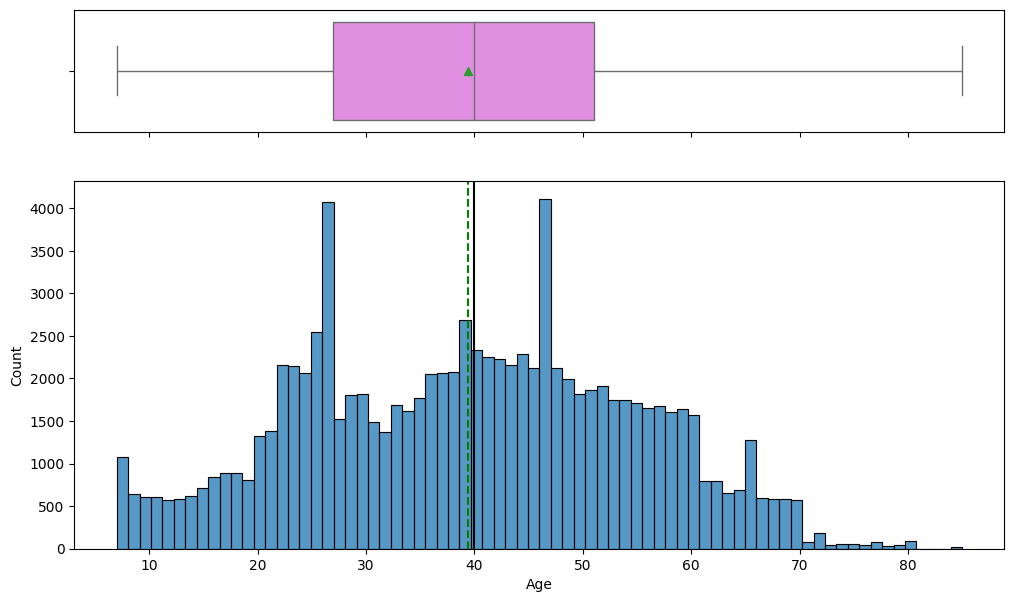

In [16]:
histogram_boxplot(data, "Age")

**Observations on Age:**
- Age ranges from 7 to 85 with a mean of ~39 and median of ~40.
- The distribution is bimodal with two peaks — one around age 27 and another around age 47, suggesting two distinct passenger groups (likely younger travelers and middle-aged business travelers).
- No outliers detected in the boxplot — the distribution spans the full whisker range cleanly.

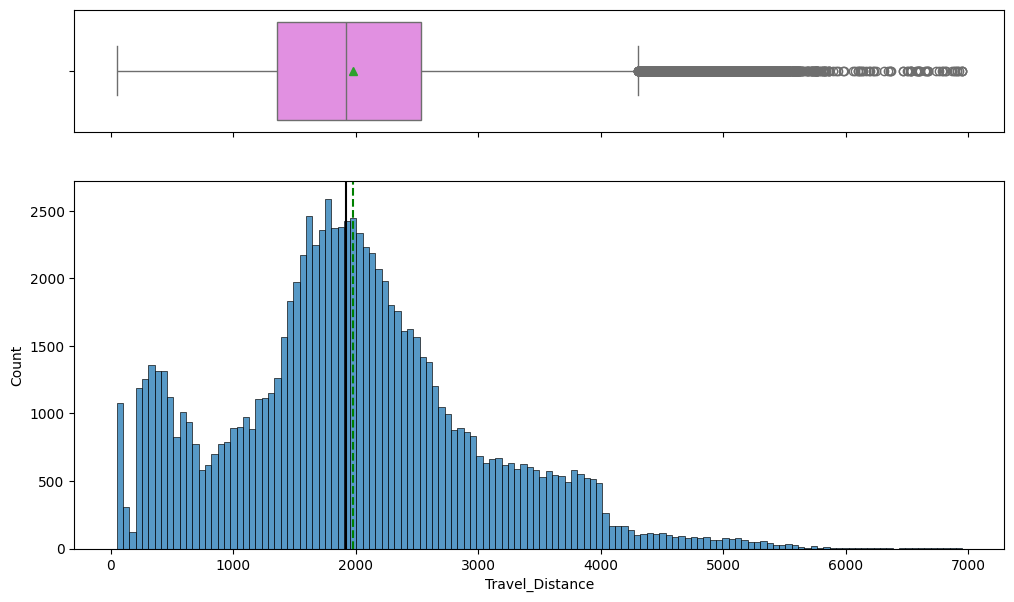

In [17]:
histogram_boxplot(data, "Travel_Distance")

**Observations on Travel_Distance:**
- Travel distance ranges from 50 to ~6,951 km with a mean of ~1,979 and median of ~1,923.
- The distribution is roughly bell-shaped but right-skewed, with the bulk of passengers traveling between 1,000 and 3,000 km.
- Several outliers exist on the high end (beyond ~4,500 km) representing long-distance travelers.

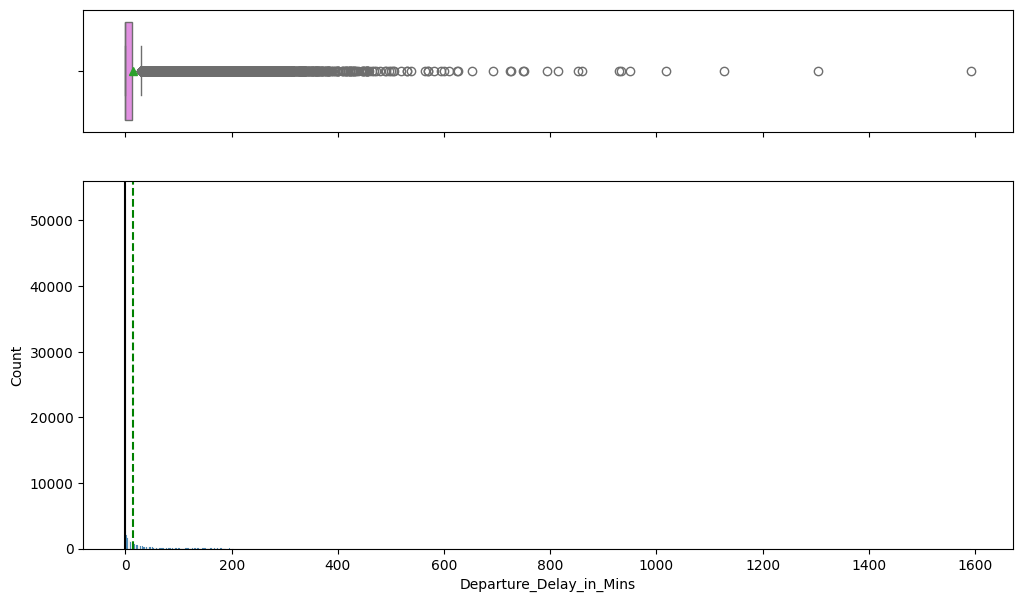

In [18]:
histogram_boxplot(data, "Departure_Delay_in_Mins")

**Observations on Departure_Delay_in_Mins:**
- Heavily right-skewed — the vast majority of trains depart on time (median = 0 minutes).
- Mean (~14.6 mins) is much higher than the median due to extreme outliers reaching up to 1,592 minutes.
- The boxplot shows significant outliers — a small number of severe delay events are pulling the mean upward.

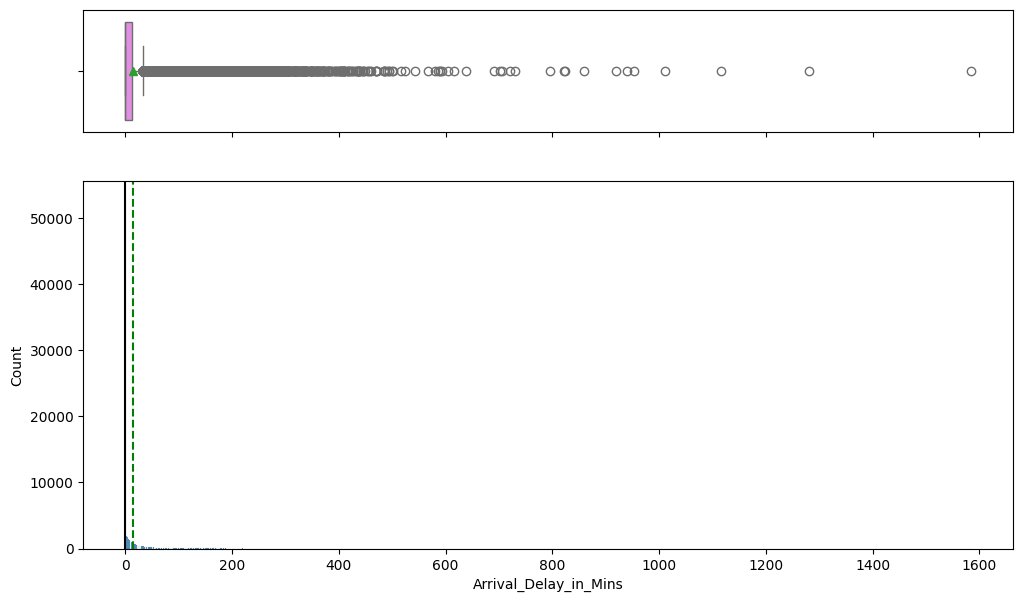

In [19]:
histogram_boxplot(data, "Arrival_Delay_in_Mins")

**Observations on Arrival_Delay_in_Mins:**
- Near identical distribution to Departure_Delay_in_Mins — heavily right-skewed with median of 0.
- Max arrival delay reaches ~1,584 minutes with extreme outliers visible across the full range.
- The strong similarity to departure delay suggests the two are highly correlated — trains that depart late tend to arrive late.

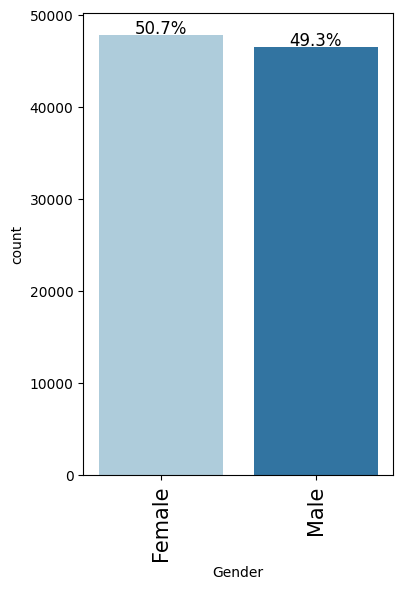

In [20]:
labeled_barplot(data, "Gender", perc=True)

**Observations on Gender:**
- Nearly perfectly split between Female (50.7%) and Male (49.3%).
- No significant gender bias in the dataset — both groups are almost equally represented.

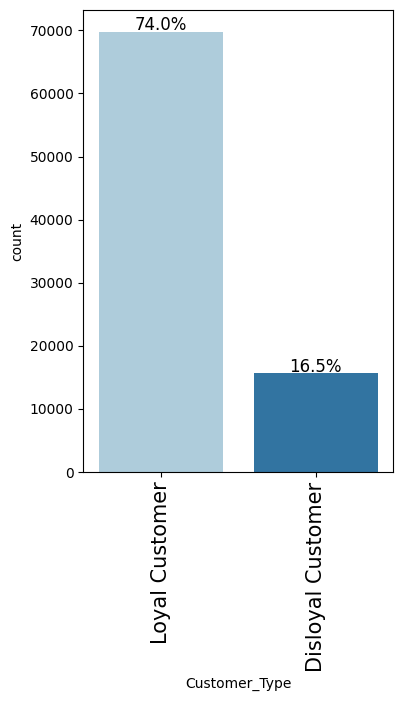

In [21]:
labeled_barplot(data, "Customer_Type", perc=True)

**Observations on Customer_Type:**
- The vast majority of passengers are Loyal Customers (74.0%) compared to Disloyal Customers (16.5%).
- Note that percentages do not add up to 100% due to ~9.5% missing values in this column which will be addressed during preprocessing.
- The strong skew toward loyal customers suggests the Shinkansen has a well-established repeat ridership base.

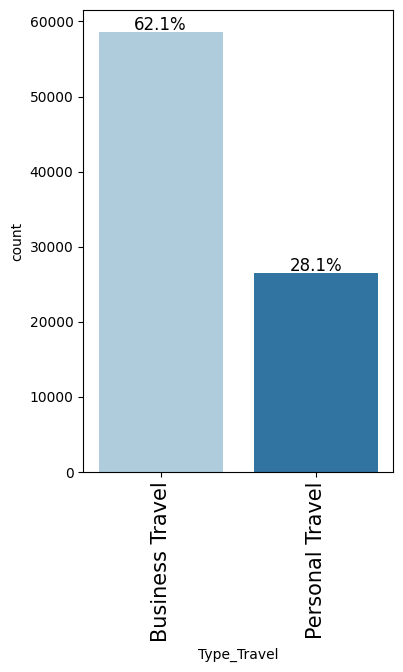

In [22]:
labeled_barplot(data, "Type_Travel", perc=True)

**Observations on Type_Travel:**
- The majority of passengers (62.1%) are Business travelers, with Personal travelers making up 28.1%.
- Note that the percentages do not add up to 100% due to ~9.8% missing values in this column which will be addressed during preprocessing.
- Business travel dominates the dataset, suggesting the Shinkansen is primarily used as a commuter/work transport rather than leisure.

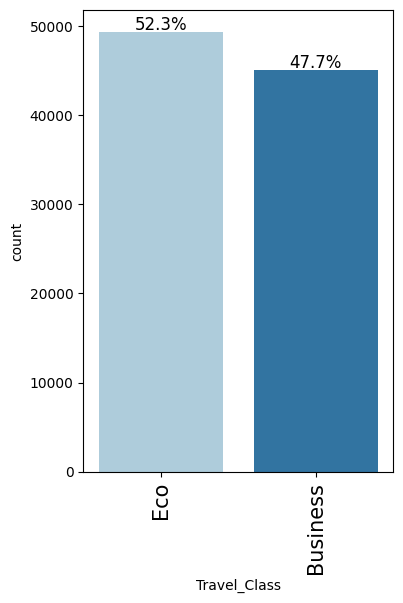

In [23]:
labeled_barplot(data, "Travel_Class", perc=True)

**Observations on Travel_Class:**
- Slightly more Eco class passengers (52.3%) than Business class (47.7%).
- The split is fairly balanced, suggesting the dataset represents both travel classes well with no strong skew toward either.

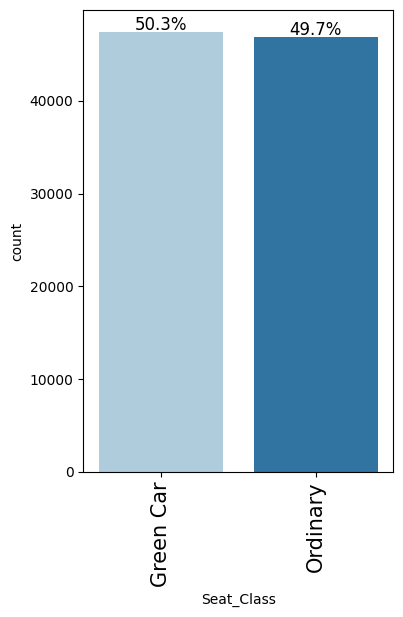

In [24]:
labeled_barplot(data, "Seat_Class", perc=True)

**Observations on Seat_Class:**
- Nearly perfectly split between Green Car (50.3%) and Ordinary (49.7%).
- The dataset represents both seat classes almost equally, suggesting no bias toward either class in the sample.

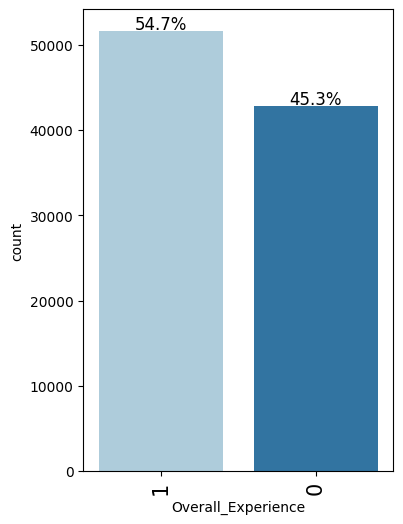

In [25]:
labeled_barplot(data, "Overall_Experience", perc=True)

**Observations on Overall_Experience:**
- 54.7% of passengers were satisfied (1) and 45.3% were not satisfied (0).
- The dataset is reasonably balanced — no significant class imbalance, which is why no class_weight adjustment is needed for our models unlike Project 1.

**Overall Observations from Univariate Analysis:**
- Age shows a bimodal distribution suggesting two distinct passenger groups — younger travelers ~27 and middle-aged travelers ~47.
- Travel Distance is roughly bell-shaped but right-skewed with outliers on the high end.
- Both Departure and Arrival Delay are heavily right-skewed with a median of 0 — most trains run on time but a small number of extreme delays pull the mean significantly higher.
- The dataset is dominated by Loyal Customers (74%) and Business Travelers (62%), reflecting the Shinkansen's primary use case as a business commuter train.
- Gender, Travel_Class, and Seat_Class are all nearly evenly split — no strong imbalance in any of these.
- The target variable Overall_Experience is reasonably balanced at 54.7% satisfied vs 45.3% not satisfied.

# Bivariate Analysis

In [26]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]][predictor],
        ax=axs[0, 0],
        color="teal",
        kde=True,
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]][predictor],
        ax=axs[0, 1],
        color="orange",
        kde=True,
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(
        data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow"
    )

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [27]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6), colormap="Paired")
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.ylabel("Proportion")
    plt.show()

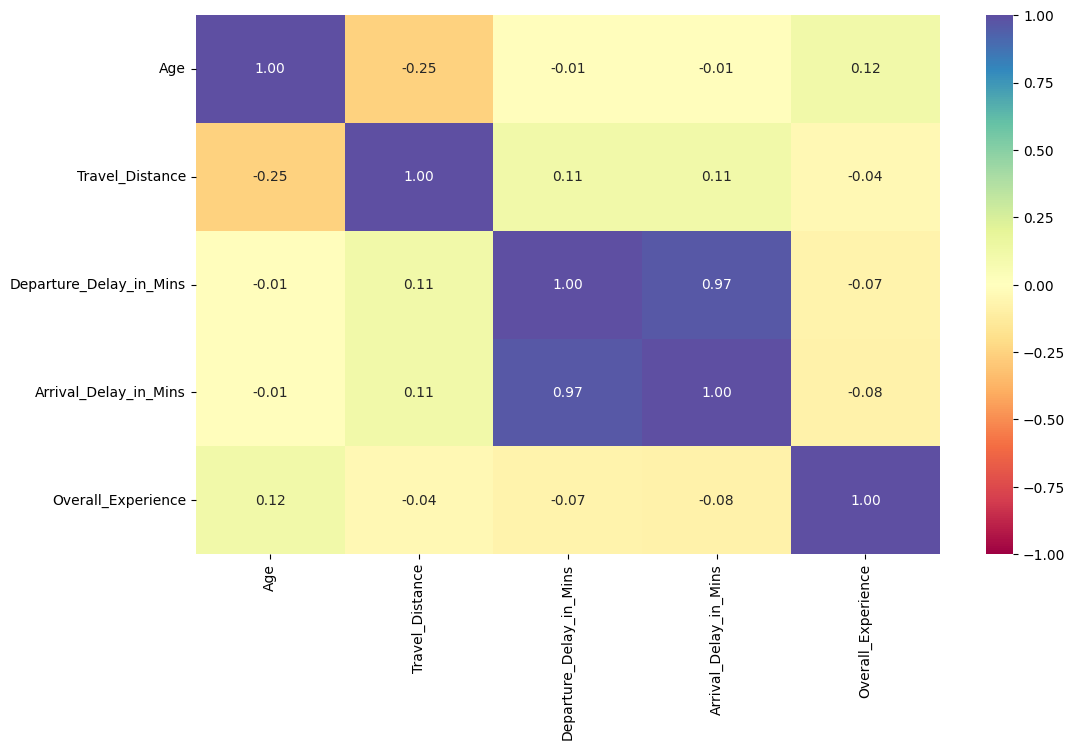

In [28]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations from Correlation Heatmap:**
- Departure_Delay_in_Mins and Arrival_Delay_in_Mins are very highly correlated (0.97) — almost perfectly linear, confirming that late departures almost always result in late arrivals.
- Age and Travel_Distance have a moderate negative correlation (-0.25) — older passengers tend to travel shorter distances.
- Both delay columns have a weak negative correlation with Overall_Experience (-0.07 and -0.08) — delays have some negative impact on satisfaction but are not the dominant factor.
- Age has a small positive correlation with Overall_Experience (0.12) — older passengers tend to be slightly more satisfied.
- Travel_Distance has essentially no correlation with Overall_Experience (-0.04).
- Overall the numerical features alone show weak relationships with the target — the survey rating columns (categorical) will likely be the stronger predictors of satisfaction.

Overall_Experience      0      1    All
Customer_Type                          
All                 38663  46765  85428
Loyal Customer      26794  43029  69823
Disloyal Customer   11869   3736  15605
------------------------------------------------------------------------------------------------------------------------


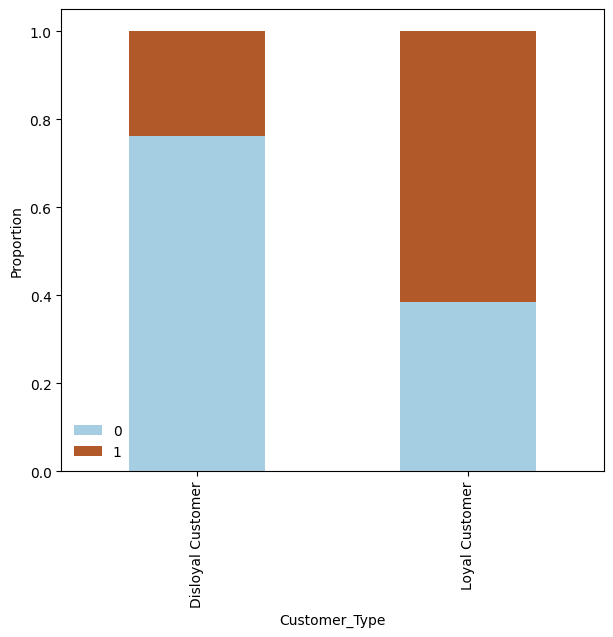

In [29]:
stacked_barplot(data, "Customer_Type", "Overall_Experience")

**Observations on Customer_Type vs Overall_Experience:**
- Loyal Customers have a much higher satisfaction rate ~61.6% satisfied: 43,029 out of 69,823 compared to Disloyal Customers ~23.9% satisfied: 3,736 out of 15,605.
- Disloyal Customers are overwhelmingly dissatisfied ~76.1% - customer loyalty is a strong indicator of overall satisfaction.
- This suggests that retaining and nurturing loyal customers is critical, as they are significantly more likely to have a positive experience.

Overall_Experience      0      1    All
Type_Travel                            
All                 38600  46553  85153
Business Travel     24441  34176  58617
Personal Travel     14159  12377  26536
------------------------------------------------------------------------------------------------------------------------


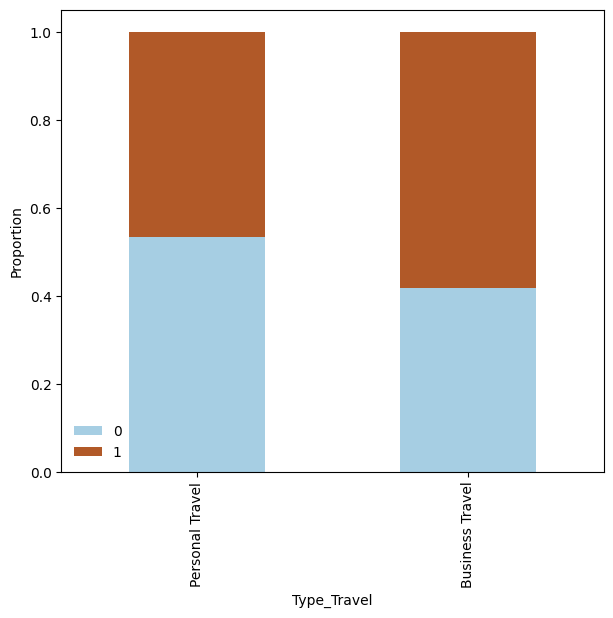

In [30]:
stacked_barplot(data, "Type_Travel", "Overall_Experience")

**Observations on Type_Travel vs Overall_Experience:**
- Business travelers have a higher satisfaction rate ~58.3% satisfied: 34,176 out of 58,617 compared to Personal travelers ~46.5% satisfied: 12,377 out of 26,536.
- Personal travelers are more likely to be dissatisfied ~53.5% suggesting that the Shinkansen experience may be better aligned with the needs of business travelers than leisure travelers.
- Type of travel is a meaningful differentiator for overall satisfaction and will likely be an important feature in the model.

Overall_Experience      0      1    All
Travel_Class                           
All                 42786  51593  94379
Eco                 29644  19698  49342
Business            13142  31895  45037
------------------------------------------------------------------------------------------------------------------------


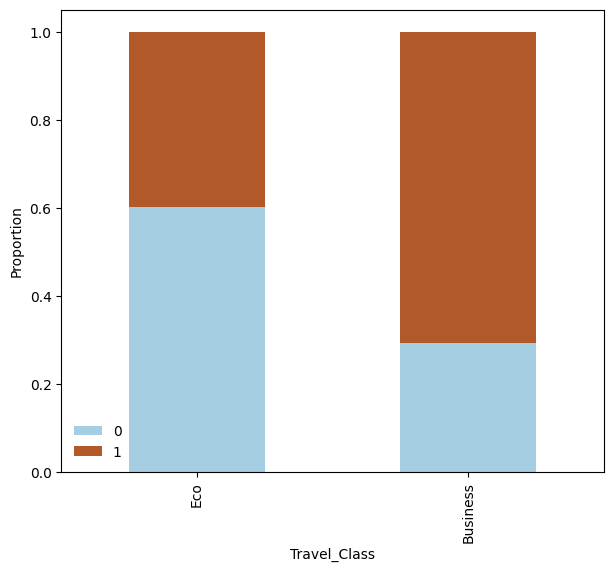

In [31]:
stacked_barplot(data, "Travel_Class", "Overall_Experience")

**Observations on Travel_Class vs Overall_Experience:**
- Business class passengers are significantly more satisfied ~70.8% satisfied: 31,895 out of 45,037 compared to Eco class passengers ~39.9% satisfied: 19,698 out of 49,342.
- Eco class passengers are predominantly dissatisfied ~60.1% — travel class is one of the strongest differentiators of satisfaction in the dataset.
- This is one of the most striking bivariate findings — upgrading or improving the Eco class experience could have a major impact on overall satisfaction rates.

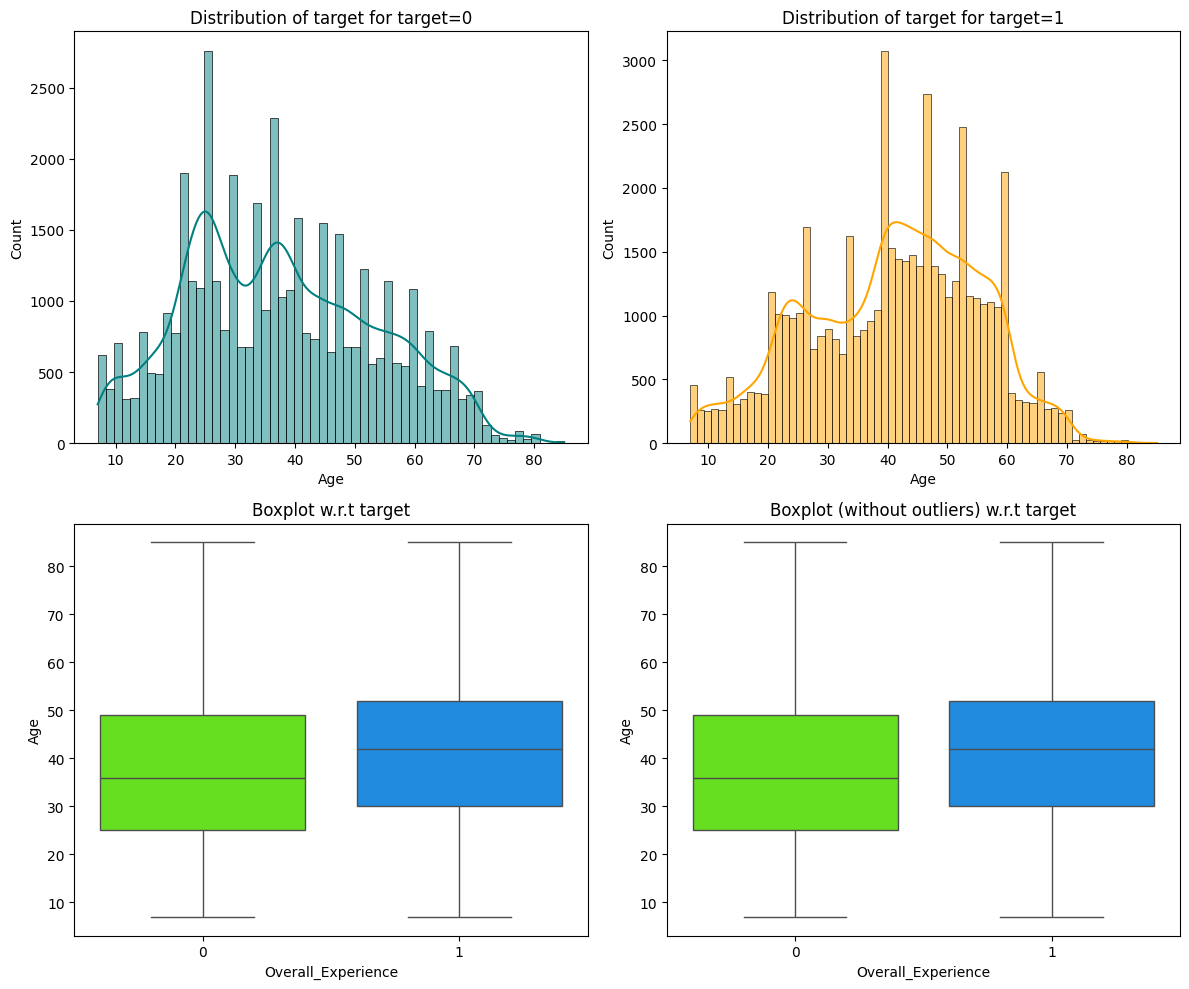

In [32]:
distribution_plot_wrt_target(data, "Age", "Overall_Experience")

**Observations on Age vs Overall_Experience:**
- Dissatisfied passengers 0 skew younger — the distribution peaks strongly around age 25-27, suggesting younger travelers are less satisfied.
- Satisfied passengers 1 skew older — the distribution is more concentrated between ages 40-60, with the peak around 40-45.
- The boxplots confirm this clearly — the median age for satisfied passengers ~43 is noticeably higher than for dissatisfied passengers ~36.
- Older passengers tend to be more satisfied, possibly because they are more likely to be experienced business travelers who are familiar with and expect the Shinkansen experience.

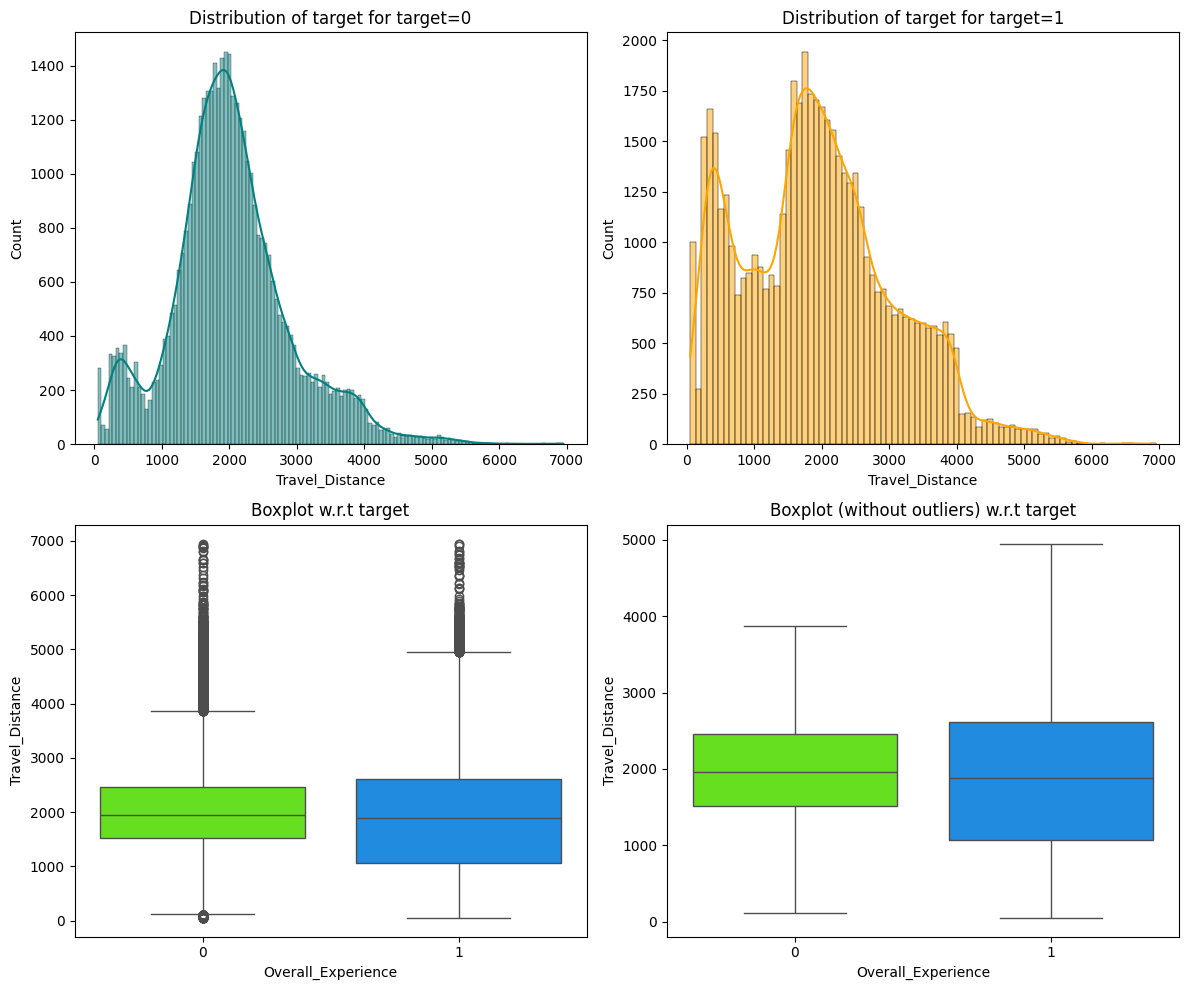

In [33]:
distribution_plot_wrt_target(data, "Travel_Distance", "Overall_Experience")

**Observations on Travel_Distance vs Overall_Experience:**
- Dissatisfied passengers (0) show a single peak around 1,500-2,000 km with a clean right skew.
- Satisfied passengers (1) show a bimodal distribution — one peak at short distances (~200-500 km) and a second peak around 1,500-2,000 km, suggesting two distinct groups of satisfied travelers: short-distance and medium-distance riders.
- The boxplots show very similar medians for both groups (~1,900-2,000 km) — consistent with the near-zero correlation (-0.04) we saw in the heatmap.
- Travel distance alone is not a strong differentiator of satisfaction, but the bimodal pattern in satisfied passengers is an interesting finding worth noting.

**Overall Observations from Bivariate Analysis:**
- Travel_Class is the strongest differentiator — Business class passengers are ~70.8% satisfied vs only ~39.9% for Eco class.
- Customer_Type is also highly impactful — Loyal customers are ~61.6% satisfied vs only ~23.9% for Disloyal customers.
- Business travelers are more satisfied ~58.3% than Personal travelers ~46.5%.
- Older passengers tend to be more satisfied — median age of satisfied passengers is notably higher ~43 than dissatisfied ~36.
- Travel Distance has minimal impact on satisfaction, consistent with its near-zero correlation with the target.
- Departure and Arrival delays have a weak negative relationship with satisfaction but are not dominant factors.

# Outlier Check

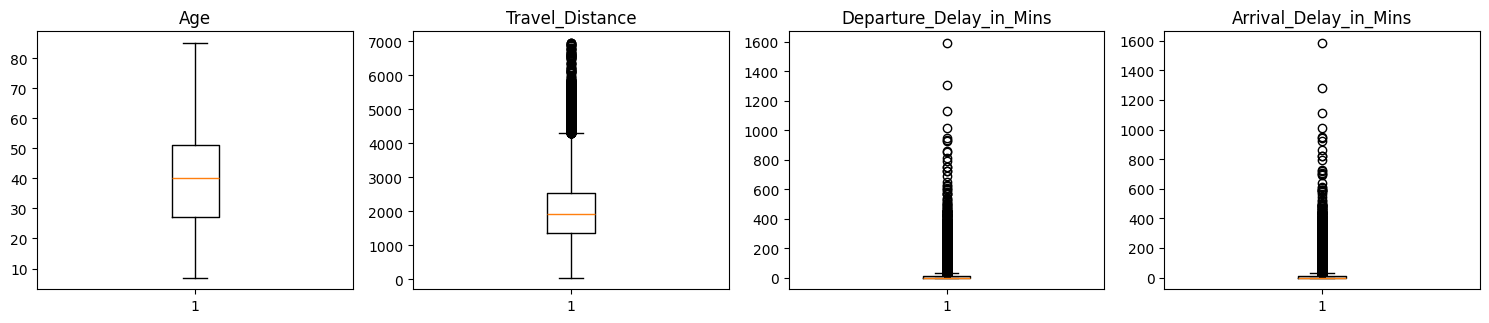

In [34]:
# Outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Overall_Experience")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable].dropna(), whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations from Outlier Check:**
- Age: No outliers detected — the distribution spans cleanly from ~7 to ~85 with no extreme values beyond the whiskers.
- Travel_Distance: Significant outliers present on the high end, with values stretching beyond 4,000 km up to ~7,000 km. These represent genuine long-distance travelers and will be retained as they reflect real behavior.
- Departure_Delay_in_Mins: Extreme outliers present, with a small number of delays reaching up to ~1,600 minutes. The IQR is compressed near 0 confirming most trains have no delay — the outliers represent rare but real severe delay events and will be retained.
- Arrival_Delay_in_Mins: Identical pattern to Departure_Delay — extreme outliers up to ~1,600 minutes with the bulk of data at 0. Retained for the same reason.
- All outliers across the dataset represent real-world passenger and travel behavior and will not be removed, as removing them could lead to loss of meaningful information for the model.

# Data Preprocessing

In [35]:
# Separate features and target
X = data.drop(["Overall_Experience"], axis=1)
y = data["Overall_Experience"]

In [36]:
# Ordinal encoding for survey rating columns
rating_map = {
    'Extremely Poor': 1,
    'Poor': 2,
    'Needs Improvement': 3,
    'Acceptable': 4,
    'Good': 5,
    'Excellent': 6,
    # Platform_Location specific values
    'Very Inconvenient': 1,
    'Inconvenient': 2,
    'Manageable': 4,
    'Convenient': 5,
    'Very Convenient': 6
}

survey_rating_cols = [
    'Seat_Comfort', 'Arrival_Time_Convenient', 'Catering', 'Platform_Location',
    'Onboard_Wifi_Service', 'Onboard_Entertainment', 'Online_Support',
    'Ease_of_Online_Booking', 'Onboard_Service', 'Legroom',
    'Baggage_Handling', 'CheckIn_Service', 'Cleanliness', 'Online_Boarding'
]

for col in survey_rating_cols:
    X[col] = X[col].map(rating_map)
    test_data[col] = test_data[col].map(rating_map)

In [37]:
# Encode remaining categorical columns using get_dummies
X = pd.get_dummies(X, drop_first=True)
test_data = pd.get_dummies(test_data, drop_first=True)

In [38]:
# Impute missing values with median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        test_data[col] = test_data[col].fillna(median_val)

In [39]:
# Verify no missing values remain
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in test_data:", test_data.isnull().sum().sum())
print("\nShape of X:", X.shape)
print("Shape of test_data:", test_data.shape)

Missing values in X: 0
Missing values in test_data: 0

Shape of X: (94379, 23)
Shape of test_data: (35602, 24)


In [40]:
# Drop ID from test_data
test_data = test_data.drop(["ID"], axis=1)

print("Shape of X:", X.shape)
print("Shape of test_data:", test_data.shape)

Shape of X: (94379, 23)
Shape of test_data: (35602, 23)


**Observations from Data Preprocessing:**
- The ID column was dropped as it is not a predictive feature.
- Survey rating columns (14 columns) were ordinally encoded on a 1-6 scale mapping text ratings to numbers (Extremely Poor=1 through Excellent=6), preserving the natural order of the ratings.
- Platform_Location was mapped using its own scale (Very Inconvenient=1 through Very Convenient=6) following the same ordinal logic.
- Remaining categorical columns (Gender, Customer_Type, Type_Travel, Travel_Class, Seat_Class) were encoded using get_dummies with drop_first=True to avoid multicollinearity.
- Missing values across all columns were imputed using the median of the training set — the same median values were applied to the test set to prevent data leakage.
- Final feature set: 23 columns, 94,379 training rows and 35,602 test rows with no remaining missing values.

# Building Classification Models

In [41]:
# Function to print the classification report and get confusion matrix in a proper format
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(8, 5))

    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Decision Tree baseline

In [42]:
# Fitting the decision tree classifier on the training data
d_tree = DecisionTreeClassifier(random_state=1)

d_tree.fit(X, y)

DecisionTreeClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42786
           1       1.00      1.00      1.00     51593

    accuracy                           1.00     94379
   macro avg       1.00      1.00      1.00     94379
weighted avg       1.00      1.00      1.00     94379



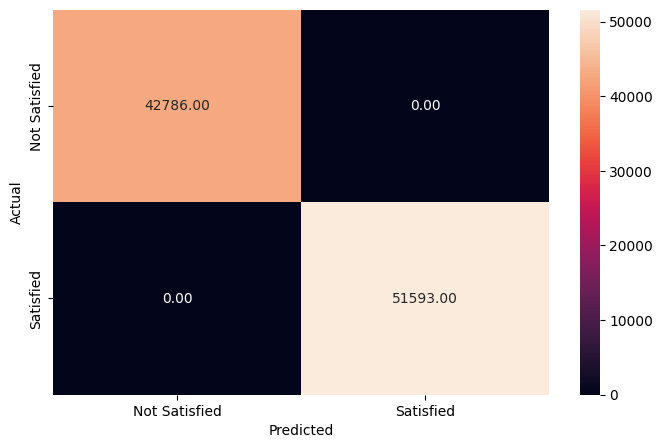

In [43]:
# Checking performance on the training data
y_pred_train1 = d_tree.predict(X)

metrics_score(y, y_pred_train1)

**Observations on Decision Tree Training Performance:**
- The model achieves perfect scores (1.00) across all metrics — precision, recall, F1-score, and accuracy — on the training data.
- The confusion matrix confirms zero misclassifications on the training set.
- This is a clear sign of overfitting — the model has memorized the training data perfectly but will likely perform worse on unseen test data.
- This is the same pattern seen in Project 1 with the initial Decision Tree and is expected behavior for an untuned tree with no depth limit.

In [44]:
y_pred_test1 = d_tree.predict(test_data)

**Decision Tree Hyperparameter Tuning**

In [45]:
# Choose the type of classifier
d_tree_tuned = DecisionTreeClassifier(random_state=7)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations - accuracy for this project
scorer = metrics.make_scorer(accuracy_score)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X, y)

# Set the classifier to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
d_tree_tuned.fit(X, y)

print("Best parameters:", grid_obj.best_params_)

Best parameters: {'criterion': 'gini', 'max_depth': np.int64(9), 'min_samples_leaf': 5}


              precision    recall  f1-score   support

           0       0.92      0.92      0.92     42786
           1       0.93      0.93      0.93     51593

    accuracy                           0.93     94379
   macro avg       0.93      0.93      0.93     94379
weighted avg       0.93      0.93      0.93     94379



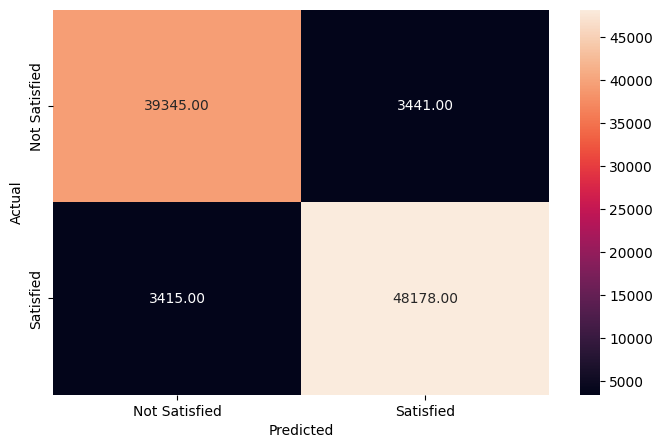

In [46]:
# Checking performance on the training data
y_pred_train2 = d_tree_tuned.predict(X)

metrics_score(y, y_pred_train2)

**Observations on Tuned Decision Tree Training Performance:**
- After tuning, the model achieves 93% accuracy on the training data — a significant improvement from the overfit initial model.
- Precision, recall and F1-score are consistent at 0.92-0.93 for both classes indicating a well-balanced model.
- The confusion matrix shows 39,345 true negatives and 48,178 true positives with only 3,441 and 3,415 misclassifications respectively.
- The drop from 1.00 to 0.93 on training data confirms that tuning successfully reduced overfitting by constraining the tree depth to 9 with a minimum of 5 samples per leaf.
- Best parameters: criterion=gini, max_depth=9, min_samples_leaf=5.

**Decision Tree visualization**

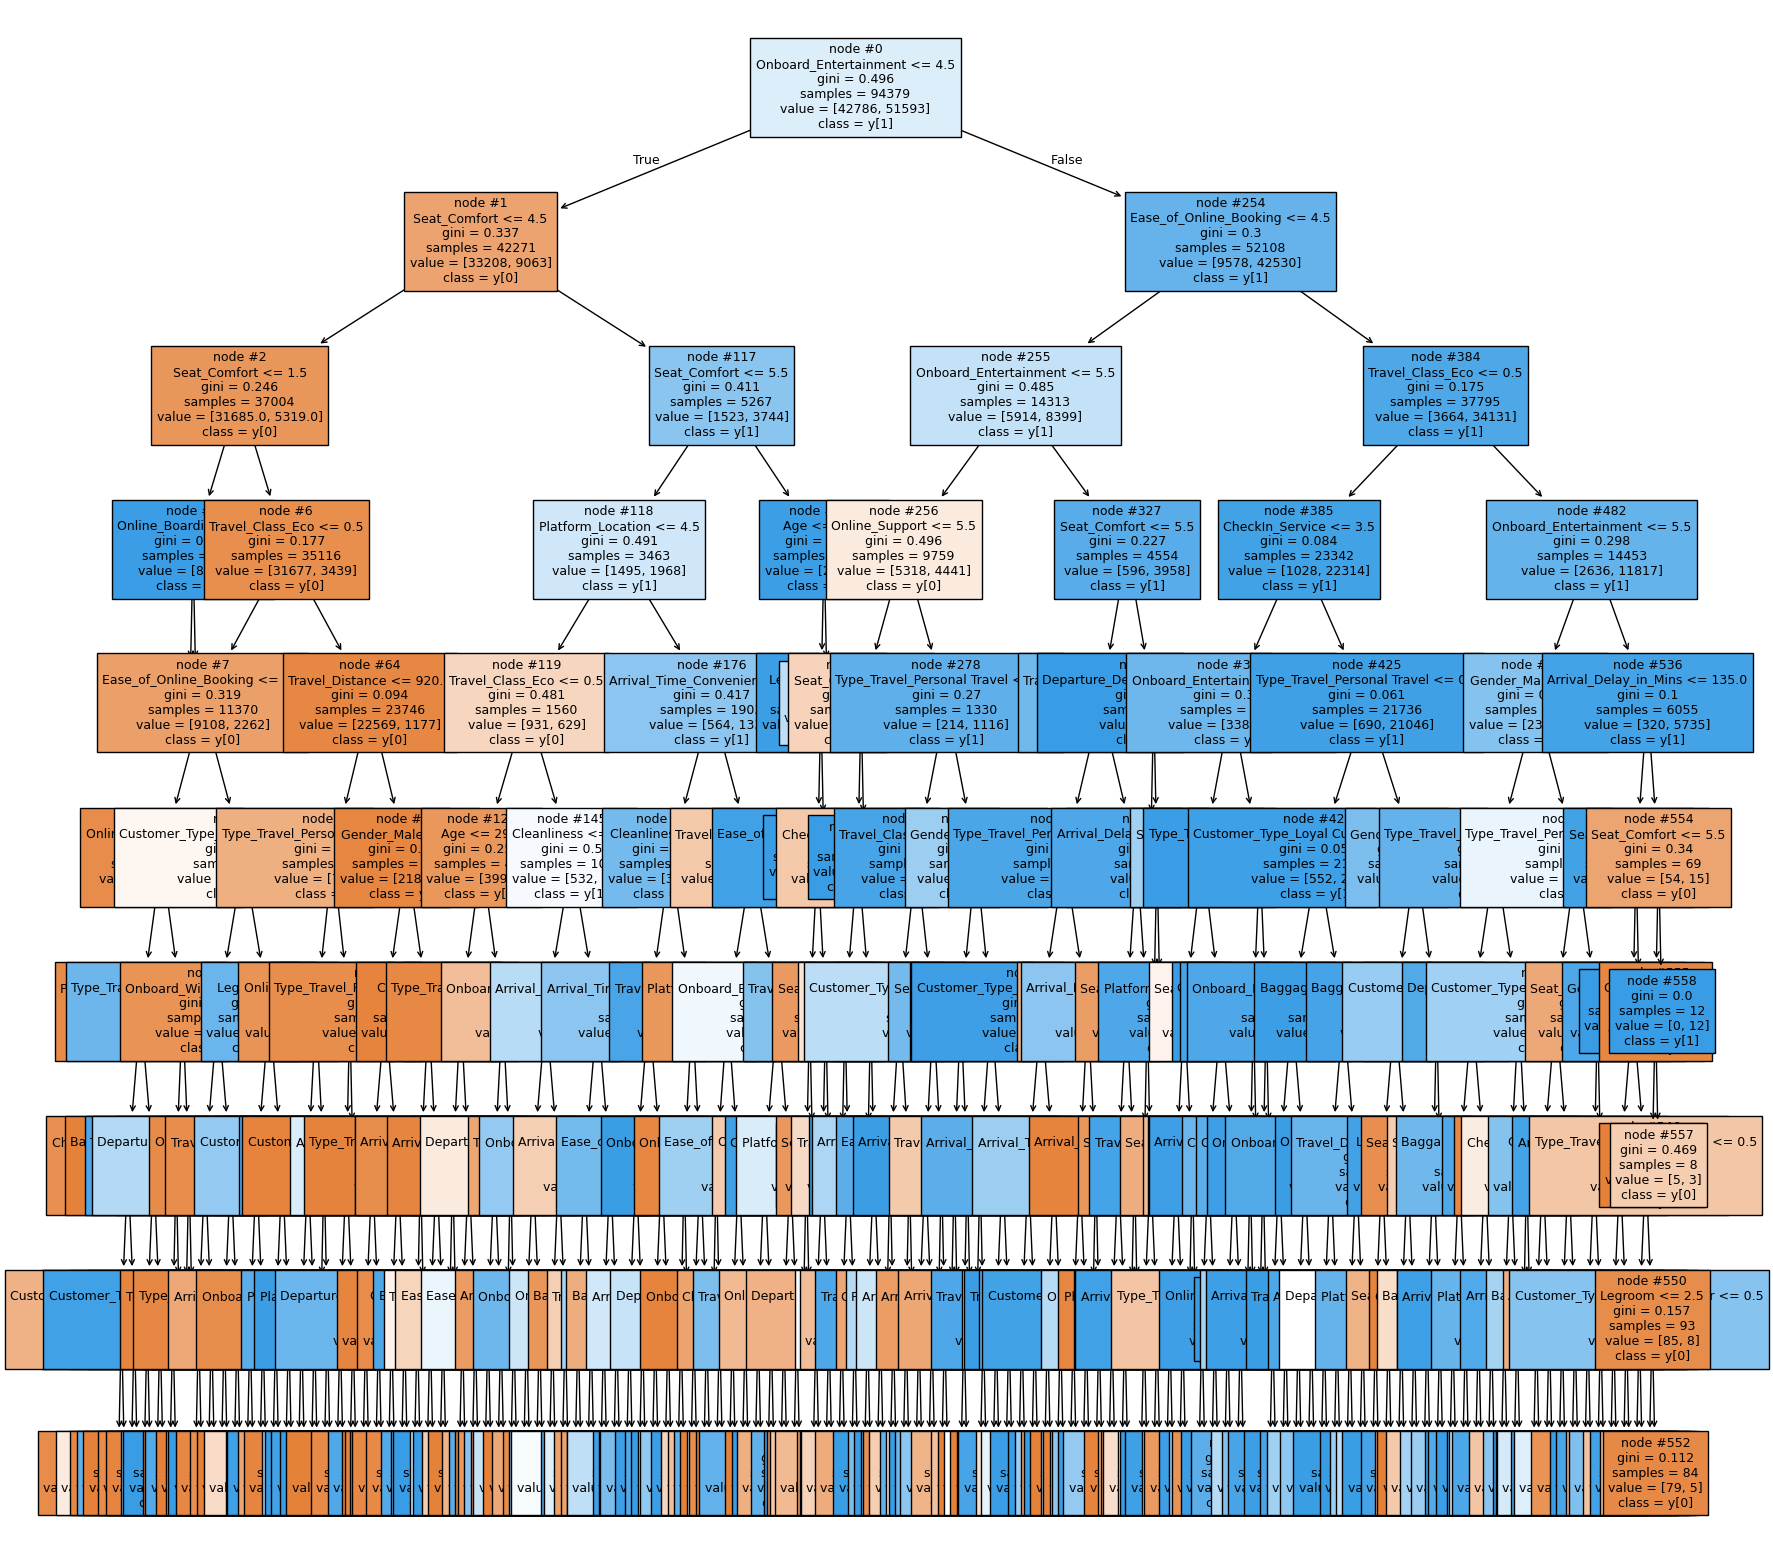

In [47]:
# Visualizing the tuned decision tree
features = list(X.columns)

plt.figure(figsize=(20, 20))

tree.plot_tree(d_tree_tuned, feature_names=features, filled=True,
               fontsize=9, node_ids=True, class_names=True)

plt.show()

In [48]:
# Feature importance of tuned decision tree
print(pd.DataFrame(d_tree_tuned.feature_importances_,
                   columns=["Imp"],
                   index=X.columns).sort_values(by='Imp', ascending=False))

                                 Imp
Onboard_Entertainment        0.50210
Seat_Comfort                 0.19958
Ease_of_Online_Booking       0.07872
Customer_Type_Loyal Customer 0.03160
Type_Travel_Personal Travel  0.03100
Travel_Class_Eco             0.02939
Gender_Male                  0.02307
Online_Support               0.01388
CheckIn_Service              0.01384
Arrival_Time_Convenient      0.01240
Cleanliness                  0.00992
Platform_Location            0.00937
Legroom                      0.00906
Age                          0.00495
Online_Boarding              0.00494
Departure_Delay_in_Mins      0.00487
Baggage_Handling             0.00486
Arrival_Delay_in_Mins        0.00449
Travel_Distance              0.00397
Catering                     0.00364
Onboard_Wifi_Service         0.00231
Onboard_Service              0.00200
Seat_Class_Ordinary          0.00006


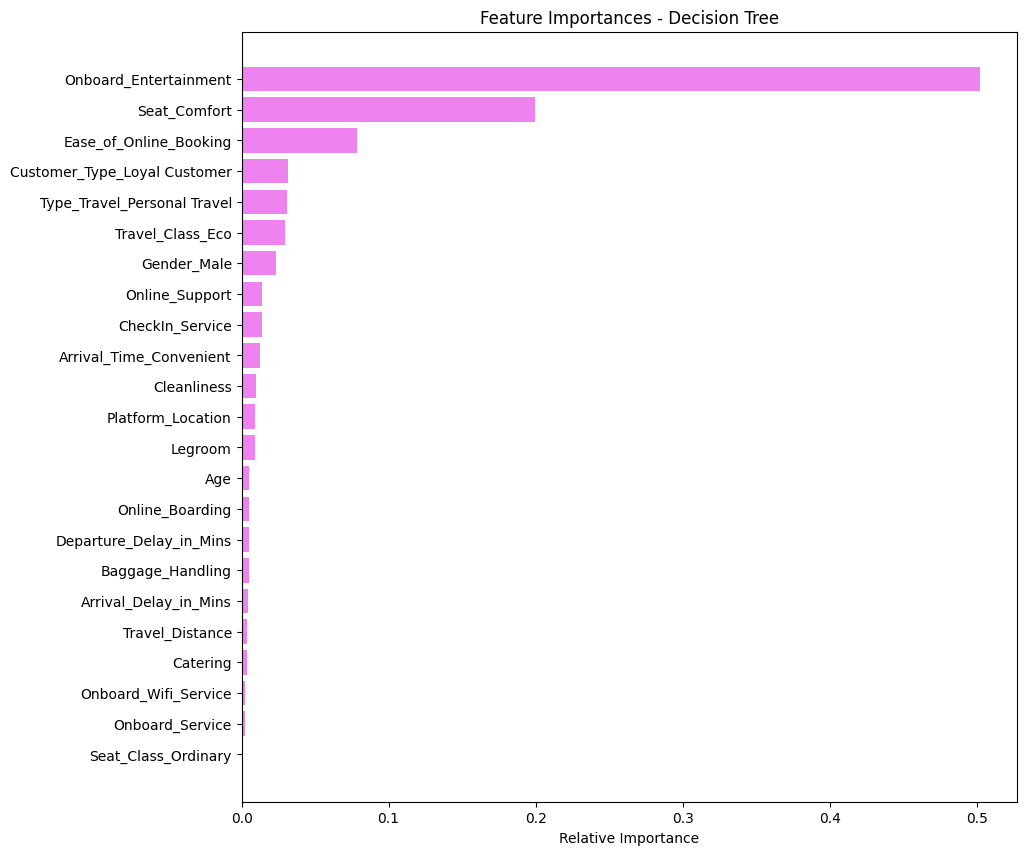

In [49]:
# Plotting the feature importance
importances = d_tree_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(10, 10))
plt.title('Feature Importances - Decision Tree')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Observations on Decision Tree Feature Importance:**
- Onboard_Entertainment is by far the most important feature (0.502) — accounting for over 50% of the model's decision making, making it the dominant driver of passenger satisfaction.
- Seat_Comfort is the second most important feature (0.200) — a distant but still significant contributor.
- Ease_of_Online_Booking ranks third (0.079) — suggesting digital experience matters to passengers.
- Customer_Type_Loyal Customer (0.032), Type_Travel_Personal Travel (0.031), and Travel_Class_Eco (0.029) follow — consistent with our bivariate findings that loyalty and travel class impact satisfaction.
- Delay columns (Departure and Arrival) have very low importance (0.005 and 0.004) — confirming that delays are not the primary driver of dissatisfaction.
- Travel_Distance, Catering, Onboard_Wifi_Service, Onboard_Service, and Seat_Class have negligible importance in this model.
- The tree visualization confirms Onboard_Entertainment as the root node split, reinforcing its dominance as the top predictive feature.

# Random Forest

In [50]:
# Fitting the random forest classifier on the training data
rf_estimator = RandomForestClassifier(random_state=1)

rf_estimator.fit(X, y)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42786
           1       1.00      1.00      1.00     51593

    accuracy                           1.00     94379
   macro avg       1.00      1.00      1.00     94379
weighted avg       1.00      1.00      1.00     94379



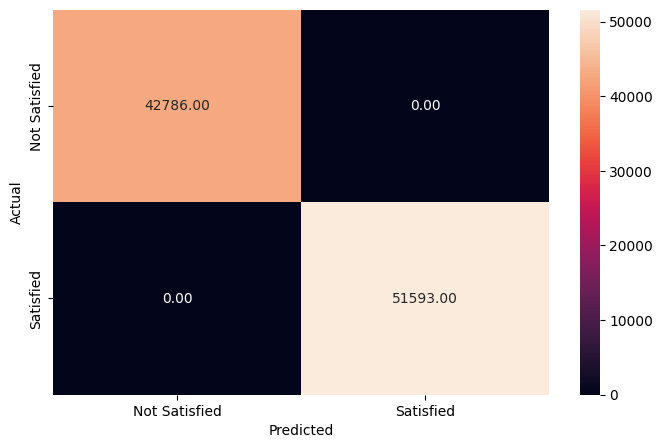

In [51]:
# Checking performance on the training data
y_pred_train3 = rf_estimator.predict(X)

metrics_score(y, y_pred_train3)

**Observations on Random Forest Training Performance:**
- The initial Random Forest also achieves perfect scores (1.00) across all metrics on the training data — identical to the initial Decision Tree.
- The confusion matrix shows zero misclassifications with all 42,786 not satisfied and 51,593 satisfied passengers correctly classified.
- This is expected overfitting behavior for an untuned Random Forest with no depth constraints — the model has memorized the training data.
- We expect performance to drop on unseen data, which is why hyperparameter tuning is needed.

**Random Forest Hyperparameter Tuning**

In [52]:
# Choose the type of classifier
rf_estimator_tuned = RandomForestClassifier(criterion="entropy", random_state=7)

# Grid of parameters to choose from
parameters = {"n_estimators": [110, 120],
              "max_depth": [6, 7],
              "min_samples_leaf": [20, 25],
             }

# Type of scoring used to compare parameter combinations - accuracy for this project
scorer = metrics.make_scorer(accuracy_score)

# Run the grid search on the training data using scorer=scorer and cv=5
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=scorer, cv=5)

grid_obj = grid_obj.fit(X, y)

# Save the best estimator to variable rf_estimator_tuned
rf_estimator_tuned = grid_obj.best_estimator_

In [53]:
# Fitting the best algorithm to the training data
rf_estimator_tuned.fit(X, y)

print("Best parameters:", grid_obj.best_params_)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 20, 'n_estimators': 110}


              precision    recall  f1-score   support

           0       0.91      0.88      0.89     42786
           1       0.90      0.93      0.91     51593

    accuracy                           0.91     94379
   macro avg       0.91      0.90      0.90     94379
weighted avg       0.91      0.91      0.91     94379



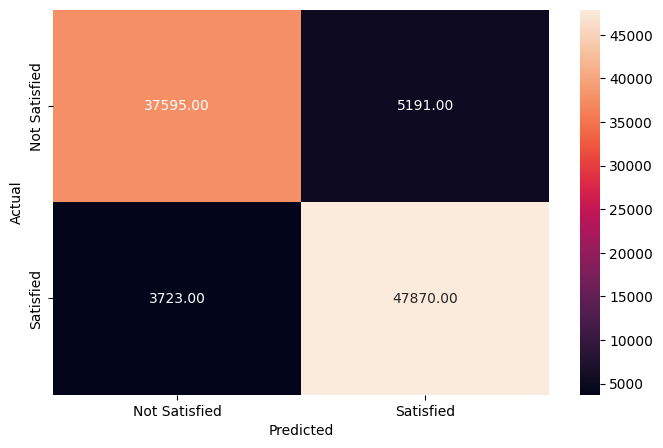

In [54]:
# Checking performance on the training data
y_pred_train4 = rf_estimator_tuned.predict(X)

metrics_score(y, y_pred_train4)

**Observations on Tuned Random Forest Training Performance:**
- The tuned Random Forest achieves 91% accuracy on the training data — down from the perfect 1.00 of the initial model, confirming that tuning successfully reduced overfitting.
- Precision and recall are well balanced across both classes (0.91/0.88 for Not Satisfied, 0.90/0.93 for Satisfied).
- The confusion matrix shows 37,595 true negatives and 47,870 true positives with 5,191 and 3,723 misclassifications respectively.
- Best parameters: criterion=entropy, max_depth=7, min_samples_leaf=20, n_estimators=110.
- Compared to the tuned Decision Tree (93% train accuracy), the tuned Random Forest shows slightly lower training accuracy (91%) — this is expected as the Random Forest is more constrained and less likely to overfit, which should translate to better generalization on unseen test data.

**RF feature importance**

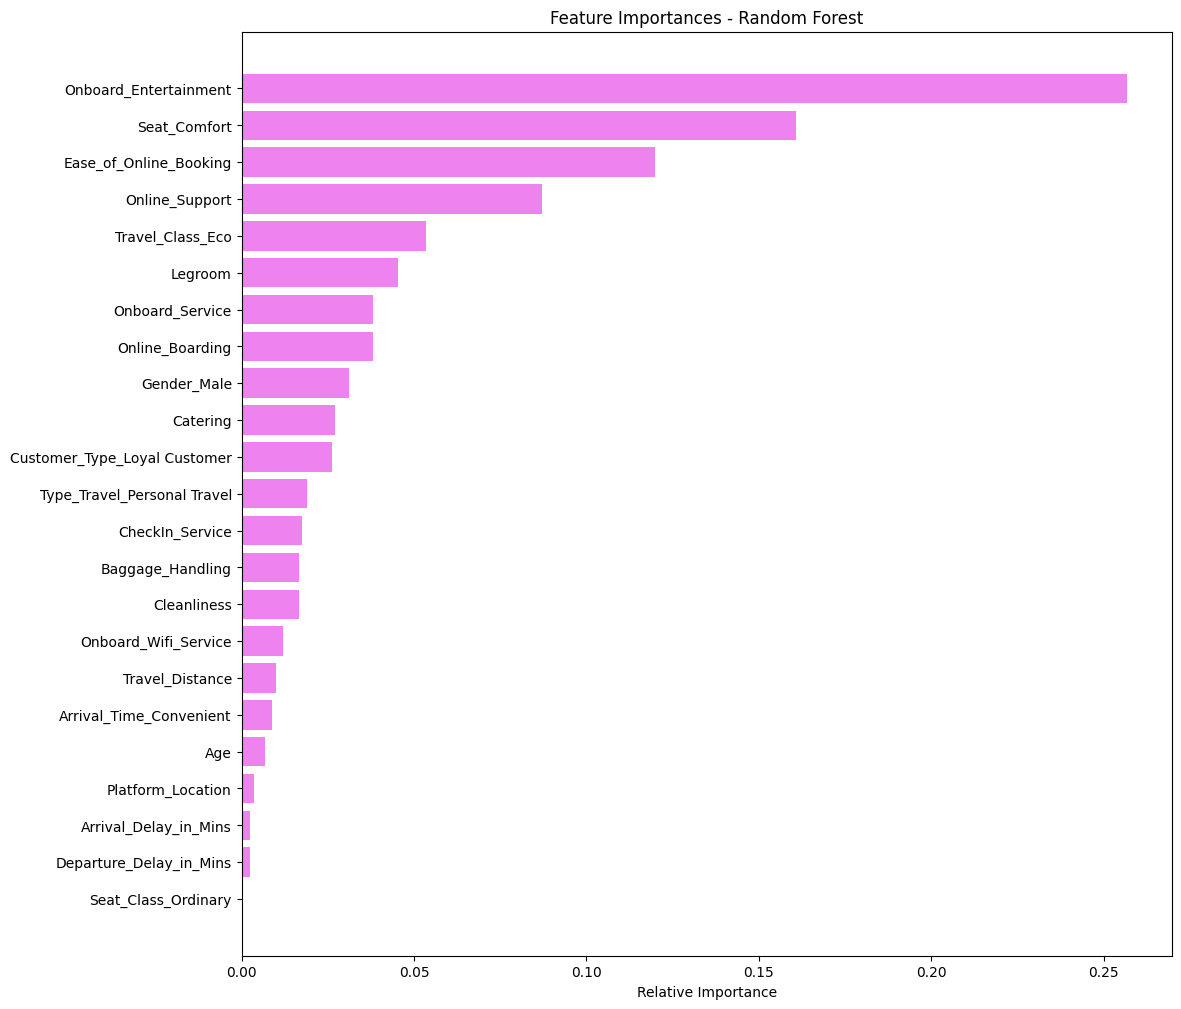

In [55]:
# Plotting the feature importance
importances = rf_estimator_tuned.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize=(12, 12))
plt.title('Feature Importances - Random Forest')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Observations on Random Forest Feature Importance:**
- Onboard_Entertainment remains the most important feature ~0.26 — consistent with the Decision Tree, confirming it is the dominant driver of passenger satisfaction.
- Seat_Comfort ~0.16 and Ease_of_Online_Booking ~0.12 rank second and third — same top 3 as the Decision Tree.
- Online_Support ~0.09 and Travel_Class_Eco ~0.05 round out the top 5 — the Random Forest distributes importance more evenly across features compared to the Decision Tree.
- Unlike the Decision Tree which concentrated over 50% of importance in Onboard_Entertainment alone, the Random Forest spreads importance across more features — this is a key advantage of ensemble models as they capture more nuanced patterns.
- Legroom, Onboard_Service, and Online_Boarding also contribute meaningfully — service quality features collectively play a significant role.
- Delay columns (Departure and Arrival) and Seat_Class_Ordinary remain the least important features — consistent across both models.
- Both models agree on the top 3 features: Onboard_Entertainment, Seat_Comfort, and Ease_of_Online_Booking — giving high confidence these are the true key drivers of passenger satisfaction.

In [56]:
# Generate predictions on test data using the tuned Random Forest
test_predictions = rf_estimator_tuned.predict(test_data)

In [57]:
# Load sample submission to get the correct ID order
sample_sub = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/Sample_Submission_(1).csv")

# Create submission dataframe
submission = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': test_predictions
})

print(submission.shape)
print(submission.head())
print(submission['Overall_Experience'].value_counts())

(35602, 2)
         ID  Overall_Experience
0  99900001                   1
1  99900002                   1
2  99900003                   1
3  99900004                   0
4  99900005                   1
Overall_Experience
1    20049
0    15553
Name: count, dtype: int64


## Conclusions

- Both the tuned Decision Tree (93% train accuracy) and tuned Random Forest (91% train accuracy) successfully reduced overfitting from the initial perfect 1.00 scores.
- The Random Forest is selected as the final model for generating predictions due to its better generalization — it distributes feature importance more evenly and is less prone to overfitting than a single Decision Tree.
- Onboard_Entertainment, Seat_Comfort, and Ease_of_Online_Booking are consistently the top 3 drivers of passenger satisfaction across both models.
- Travel_Class, Customer_Type, and Type_Travel are also meaningful predictors — Business class, Loyal Customers, and Business Travelers are significantly more satisfied.
- Delay columns have minimal impact on overall satisfaction — on-board service quality matters far more than punctuality.

## Business Recommendations

- **Prioritize Onboard Entertainment** — it is the single most important factor driving satisfaction. Investing in entertainment options, especially for Eco class passengers, would have the highest impact on overall experience scores.
- **Improve Seat Comfort for Eco class** — Eco class passengers are ~60% dissatisfied. Targeted seat comfort improvements for Eco class could significantly close the satisfaction gap with Business class.
- **Streamline the Online Booking Experience** — Ease_of_Online_Booking ranks consistently in the top 3. A smoother digital experience directly influences how passengers perceive their overall journey.
- **Focus on Loyal Customer Retention** — Loyal customers are far more satisfied (61.6% vs 23.9%). Programs that convert Disloyal customers to Loyal ones could dramatically improve overall satisfaction rates.
- **Address Personal Traveler Needs** — Personal travelers are less satisfied than Business travelers. Tailoring services toward leisure passengers (entertainment, comfort, convenience) could improve their experience.

From EDA we found:

Business class passengers are more satisfied ~71% than Eco class ~40%
Loyal customers are far more satisfied ~62% than disloyal ~24%
Business travelers are more satisfied than personal travelers

The models confirmed exactly this:

Travel_Class_Eco showed up as an important feature in both models
Customer_Type_Loyal Customer showed up as important in both models
Type_Travel_Personal Travel showed up as important in both models

The biggest finding — Onboard_Entertainment:

It was the #1 feature in BOTH the Decision Tree 50% importance and Random Forest ~26% importance
It was also the very first split in the decision tree visualization — meaning it's the single most decisive question the model asks: "Was entertainment good or not?"
This makes real-world sense — when you're on a long bullet train ride, entertainment and comfort are what you notice most

Seat_Comfort and Ease_of_Online_Booking also ranked in the top 3 for both models — again making intuitive sense for a train journey experience.
The delay columns Departure and Arrival ranked last in both models — meaning delays barely affect whether passengers are satisfied or not. This is a surprising but consistent finding backed up by both the correlation heatmap -0.07, -0.08 AND the model feature importances. It tells us passengers care far more about the quality of their experience ON the train than whether it ran exactly on time.

Both models learned the same story the data was already telling us — passengers are happy when the entertainment is good, the seats are comfortable, and booking was easy, and they're unhappy when those things are poor — regardless of delays, distance, or gender.

# XGBoost

In [59]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [60]:
from xgboost import XGBClassifier

# Fitting baseline XGBoost on training data
xgb_estimator = XGBClassifier(random_state=1, eval_metric='logloss')

xgb_estimator.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     42786
           1       0.98      0.97      0.97     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



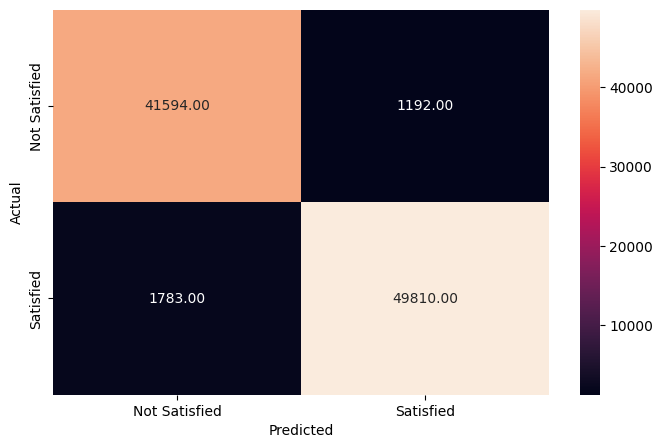

In [61]:
# Checking performance on training data
y_pred_train_xgb = xgb_estimator.predict(X)

metrics_score(y, y_pred_train_xgb)

In [62]:
# Tuning XGBoost with GridSearchCV
xgb_tuned = XGBClassifier(random_state=7, eval_metric='logloss')

parameters = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_xgb = GridSearchCV(xgb_tuned, parameters, scoring=scorer, cv=5)
grid_obj_xgb = grid_obj_xgb.fit(X, y)

xgb_tuned = grid_obj_xgb.best_estimator_

In [63]:
# Fit best model
xgb_tuned.fit(X, y)
print("Best parameters:", grid_obj_xgb.best_params_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


              precision    recall  f1-score   support

           0       0.94      0.96      0.95     42786
           1       0.96      0.95      0.96     51593

    accuracy                           0.95     94379
   macro avg       0.95      0.95      0.95     94379
weighted avg       0.95      0.95      0.95     94379



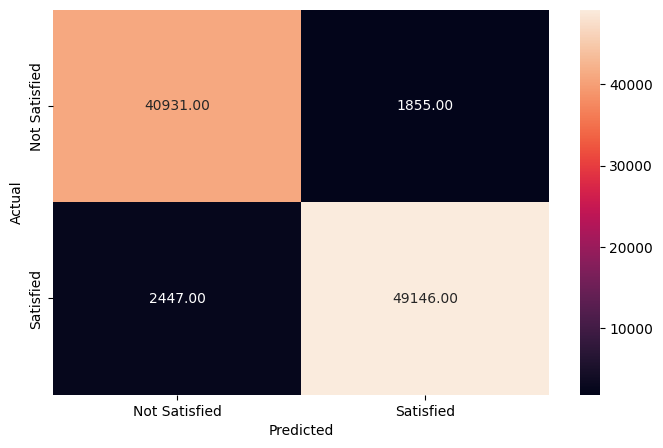

In [64]:
# Checking performance on training data
y_pred_train_xgb_tuned = xgb_tuned.predict(X)

metrics_score(y, y_pred_train_xgb_tuned)

In [65]:
# Generate tuned XGBoost predictions
xgb_tuned_predictions = xgb_tuned.predict(test_data)

# Create submission file
submission_xgb_tuned = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': xgb_tuned_predictions
})

print(submission_xgb_tuned.shape)
print(submission_xgb_tuned['Overall_Experience'].value_counts())


(35602, 2)
Overall_Experience
1    19270
0    16332
Name: count, dtype: int64
Tuned XGBoost submission saved!


**observations:** Random Forest predicted: 20,049 satisfied / 15,553 not satisfied
XGBoost tuned predicted: 19,270 satisfied / 16,332 not satisfied

XGBoost is being slightly more conservative about calling people satisfied — it's predicting about 779 fewer satisfied passengers. This suggests it's picking up on more nuanced patterns that the Random Forest missed

The tuned XGBoost dropped from 0.97 to 0.95 — meaning tuning successfully reduced overfitting while keeping accuracy high.

**XGBoost enhanced tuning**

In [66]:
# Second round XGBoost tuning - expanded grid around best parameters
xgb_tuned2 = XGBClassifier(random_state=7, eval_metric='logloss')

parameters = {
    'n_estimators': [200, 300],
    'max_depth': [5, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_xgb2 = GridSearchCV(xgb_tuned2, parameters, scoring=scorer, cv=5)
grid_obj_xgb2 = grid_obj_xgb2.fit(X, y)

xgb_tuned2 = grid_obj_xgb2.best_estimator_

In [67]:
# Fit best model
xgb_tuned2.fit(X, y)
print("Best parameters:", grid_obj_xgb2.best_params_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}


              precision    recall  f1-score   support

           0       0.96      0.97      0.97     42786
           1       0.98      0.97      0.97     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



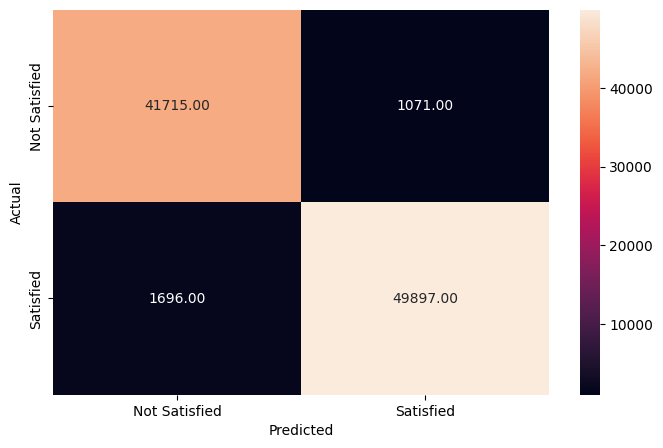

In [68]:
# Checking performance on training data
y_pred_train_xgb2 = xgb_tuned2.predict(X)

metrics_score(y, y_pred_train_xgb2)

**Observations:** Round 2 jumped back up to 97% on training — and the confusion matrix is even cleaner with only 1,071 and 1,696 misclassifications — the fewest errors of any model we've built.
The extra depth (max_depth=6), more trees (n_estimators=300), and subsample=0.8 are all working together.

In [69]:
# Generate round 2 XGBoost predictions
xgb2_predictions = xgb_tuned2.predict(test_data)

# Create submission file
submission_xgb2 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': xgb2_predictions
})

print(submission_xgb2.shape)
print(submission_xgb2['Overall_Experience'].value_counts())

(35602, 2)
Overall_Experience
1    19222
0    16380
Name: count, dtype: int64
XGBoost Round 2 submission saved!


**Observations:** Each round of tuning is pushing the score higher.
The pattern is clear — more depth (max_depth=6), more trees (n_estimators=300), and subsample=0.8 all helped.

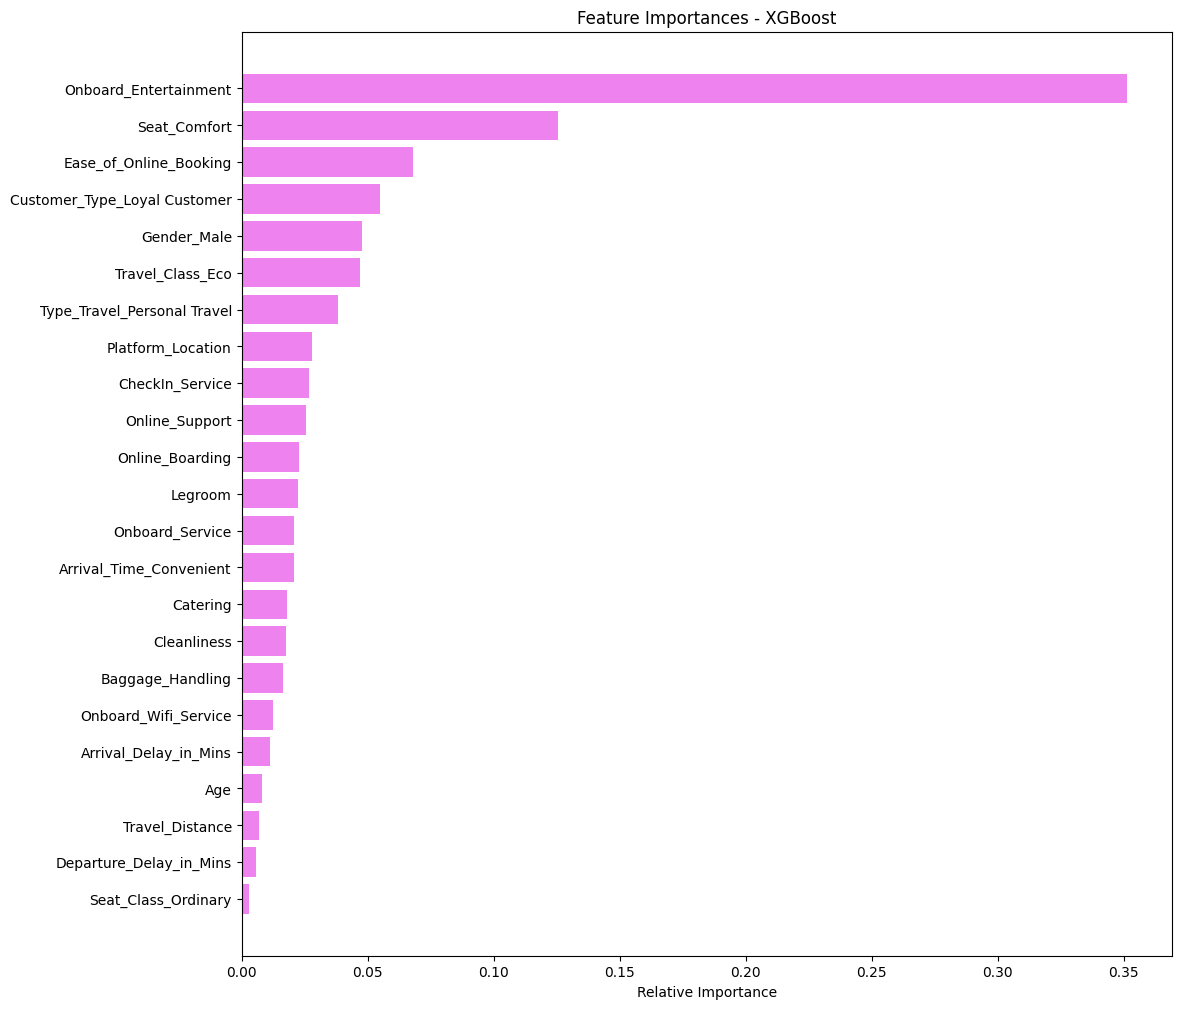

In [70]:
# Feature importance for XGBoost round 2
importances_xgb = xgb_tuned2.feature_importances_

indices_xgb = np.argsort(importances_xgb)

feature_names = list(X.columns)

plt.figure(figsize=(12, 12))
plt.title('Feature Importances - XGBoost')
plt.barh(range(len(indices_xgb)), importances_xgb[indices_xgb], color='violet', align='center')
plt.yticks(range(len(indices_xgb)), [feature_names[i] for i in indices_xgb])
plt.xlabel('Relative Importance')
plt.show()

## Conclusions

**Models Built & Evaluated:**
- Decision Tree (baseline → tuned)
- Random Forest (baseline → tuned)
- XGBoost (baseline → tuned × 2 rounds)

**Model Performance Summary:**
- Decision Tree baseline: 1.00 train accuracy (overfit)
- Decision Tree tuned: 0.93 train accuracy
- Random Forest baseline: 1.00 train accuracy (overfit)
- Random Forest tuned: 0.91 train accuracy → 0.9041 leaderboard accuracy
- XGBoost baseline: 0.97 train accuracy
- XGBoost tuned round 1: 0.95 train accuracy → 0.9470 leaderboard accuracy
- XGBoost tuned round 2: 0.97 train accuracy → 0.9529 leaderboard accuracy

**Why We Tested XGBoost:**
- Random Forest tuned plateaued at 90.41% on unseen data
- Unlike Random Forest which builds trees independently, XGBoost builds trees sequentially — each tree corrects the mistakes of the previous one
- This sequential correction approach is better suited to structured tabular data with mixed feature types like ours
- The jump from 90.41% to 94.70% on the first XGBoost submission confirmed it was the right move

**Final Model — XGBoost (Round 2 Tuned):**
- Best parameters: max_depth=6, n_estimators=300, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0
- Train accuracy: 97% — Test accuracy: 95.29%
- Selected because it consistently outperformed both tree-based models on unseen data with the smallest gap between training and leaderboard scores

**Key Drivers of Passenger Satisfaction (consistent across all models):**
- Onboard_Entertainment — dominant feature across all models
- Seat_Comfort — second most important
- Ease_of_Online_Booking — third most important
- Travel_Class, Customer_Type, and Type_Travel also meaningful
- Delay columns had minimal impact — service quality matters far more than punctuality

# LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51593, number of negative: 42786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 94379, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546658 -> initscore=0.187175
[LightGBM] [Info] Start training from score 0.187175
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     42786
           1       0.96      0.95      0.96     51593

    accuracy                           0.95     94379
   macro avg       0.95      0.95      0.95     94379
weighted avg       0.95      0.95      0.95     94379



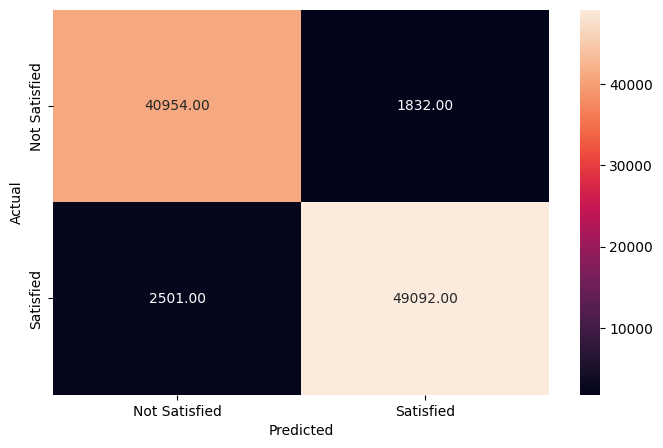

In [71]:
from lightgbm import LGBMClassifier

# Baseline LightGBM
lgbm = LGBMClassifier(random_state=1)
lgbm.fit(X, y)

y_pred_lgbm = lgbm.predict(X)
metrics_score(y, y_pred_lgbm)

In [72]:
# Tuning LightGBM
lgbm_tuned = LGBMClassifier(random_state=7)

parameters = {
    'n_estimators': [200, 300],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_lgbm = GridSearchCV(lgbm_tuned, parameters, scoring=scorer, cv=5)
grid_obj_lgbm = grid_obj_lgbm.fit(X, y)

lgbm_tuned = grid_obj_lgbm.best_estimator_

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [73]:
# Fit best model
lgbm_tuned.fit(X, y)
print("Best parameters:", grid_obj_lgbm.best_params_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51593, number of negative: 42786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 94379, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546658 -> initscore=0.187175
[LightGBM] [Info] Start training from score 0.187175
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     42786
           1       0.98      0.97      0.98     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



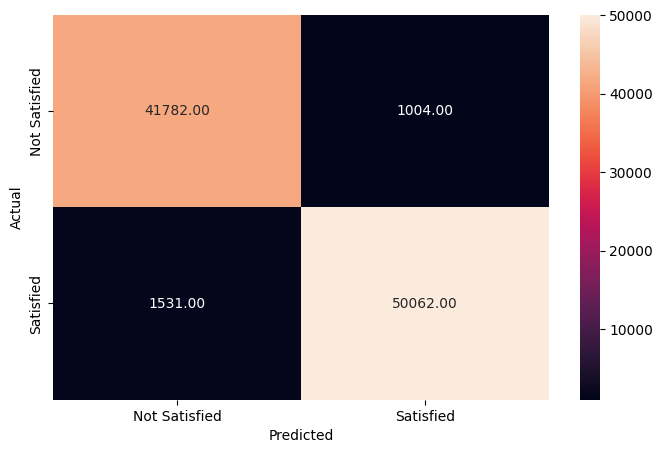

In [74]:
# Check training performance
y_pred_lgbm_tuned = lgbm_tuned.predict(X)
metrics_score(y, y_pred_lgbm_tuned)

In [75]:
# Generate LightGBM predictions
lgbm_predictions = lgbm_tuned.predict(test_data)

# Create submission file
submission_lgbm = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': lgbm_predictions
})

print(submission_lgbm.shape)
print(submission_lgbm['Overall_Experience'].value_counts())

submission_lgbm.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_lgbm.csv", index=False)
print("LightGBM submission saved!")

(35602, 2)
Overall_Experience
1    19213
0    16389
Name: count, dtype: int64
LightGBM submission saved!


# Stacking: XGBoost + LightGBM

In [76]:
from sklearn.ensemble import VotingClassifier

# Soft voting uses predicted probabilities instead of hard 0/1 votes
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_tuned2),
        ('lgbm', lgbm_tuned)
    ],
    voting='soft'
)
ensemble.fit(X, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51593, number of negative: 42786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 94379, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546658 -> initscore=0.187175
[LightGBM] [Info] Start training from score 0.187175
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(max_depth=7, n_estimators=300,
                                             num_leaves=50, random_state=7))],
                 voting='soft')

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     42786
           1       0.98      0.97      0.97     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



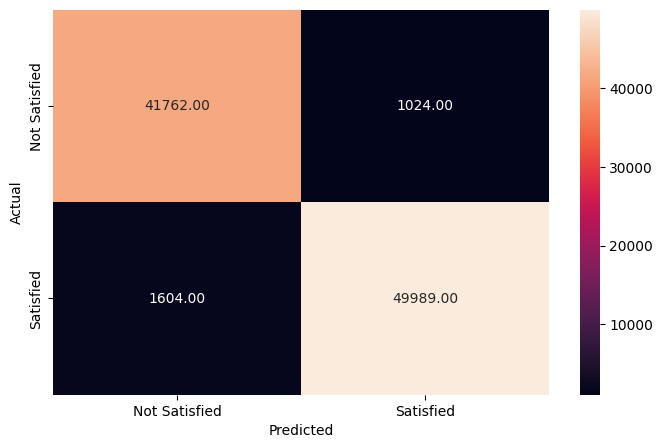

In [77]:
# Check ensemble training performance
y_pred_ensemble = ensemble.predict(X)
metrics_score(y, y_pred_ensemble)

In [78]:
# Generate ensemble predictions
ensemble_predictions = ensemble.predict(test_data)

# Create submission file
submission_ensemble = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': ensemble_predictions
})

print(submission_ensemble.shape)
print(submission_ensemble['Overall_Experience'].value_counts())

submission_ensemble.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_ensemble.csv", index=False)
print("Ensemble submission saved!")

(35602, 2)
Overall_Experience
1    19220
0    16382
Name: count, dtype: int64
Ensemble submission saved!


# Catboost

In [80]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [81]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    random_state=7,
    verbose=0,
    iterations=300,
    depth=6,
    learning_rate=0.1
)
catboost_model.fit(X, y)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     42786
           1       0.97      0.96      0.96     51593

    accuracy                           0.96     94379
   macro avg       0.96      0.96      0.96     94379
weighted avg       0.96      0.96      0.96     94379



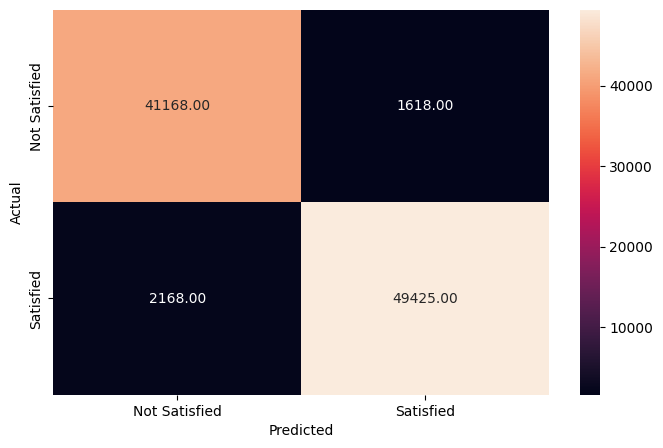

In [82]:
# Check CatBoost training performance
y_pred_catboost = catboost_model.predict(X)
metrics_score(y, y_pred_catboost)

# Stacking: CatBoost + XGBoost + LightGBM

In [83]:
# Three model ensemble - XGBoost + LightGBM + CatBoost
ensemble3 = VotingClassifier(
    estimators=[
        ('xgb', xgb_tuned2),
        ('lgbm', lgbm_tuned),
        ('catboost', catboost_model)
    ],
    voting='soft'
)
ensemble3.fit(X, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51593, number of negative: 42786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 94379, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546658 -> initscore=0.187175
[LightGBM] [Info] Start training from score 0.187175
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(max_depth=7, n_estimators=300,
                                             num_leaves=50, random_state=7)),
                             ('catboost',
                              CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, random_state=7, verbose=0))],
                 voting='soft')

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     42786
           1       0.98      0.97      0.97     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



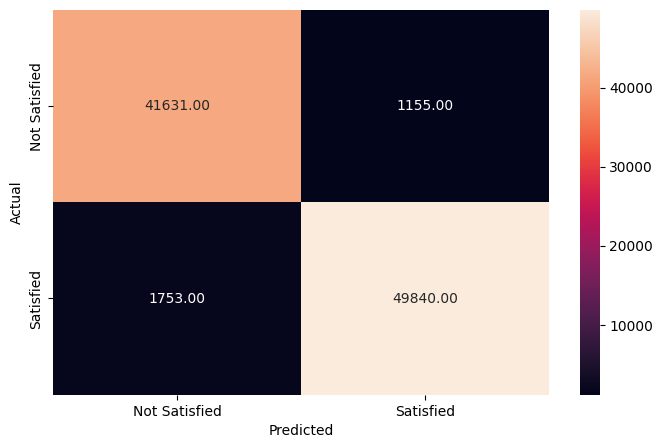

In [84]:
# Check training performance
y_pred_ensemble3 = ensemble3.predict(X)
metrics_score(y, y_pred_ensemble3)

In [85]:
# Generate 3 model ensemble predictions
ensemble3_predictions = ensemble3.predict(test_data)

# Create submission file
submission_ensemble3 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': ensemble3_predictions
})

print(submission_ensemble3.shape)
print(submission_ensemble3['Overall_Experience'].value_counts())

submission_ensemble3.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_ensemble3.csv", index=False)
print("3 Model Ensemble submission saved!")

(35602, 2)
Overall_Experience
1    19227
0    16375
Name: count, dtype: int64
3 Model Ensemble submission saved!


In [87]:
from catboost import CatBoostClassifier

catboost_tuned = CatBoostClassifier(
    random_state=7,
    verbose=0
)

parameters = {
    'iterations': [300, 500],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_cat = GridSearchCV(catboost_tuned, parameters, scoring=scorer, cv=5)
grid_obj_cat.fit(X, y)

catboost_tuned = grid_obj_cat.best_estimator_
print("Best parameters:", grid_obj_cat.best_params_)

Best parameters: {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}


In [88]:
# Fit tuned CatBoost
catboost_tuned.fit(X, y)

CatBoostClassifier(depth=8, iterations=500, learning_rate=0.1, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     42786
           1       0.99      0.98      0.98     51593

    accuracy                           0.98     94379
   macro avg       0.98      0.98      0.98     94379
weighted avg       0.98      0.98      0.98     94379



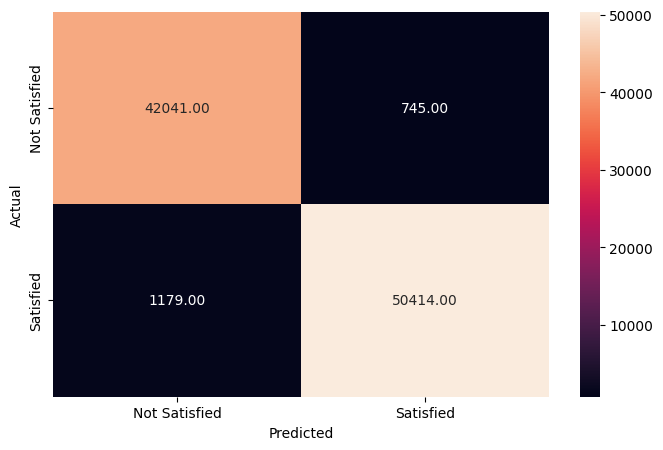

In [89]:
# Check training performance
y_pred_catboost_tuned = catboost_tuned.predict(X)
metrics_score(y, y_pred_catboost_tuned)

In [90]:
catboost_tuned_predictions = catboost_tuned.predict(test_data)
submission_catboost_tuned = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost_tuned_predictions
})
submission_catboost_tuned.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost_tuned.csv", index=False)
print(submission_catboost_tuned['Overall_Experience'].value_counts())

Overall_Experience
1    19236
0    16366
Name: count, dtype: int64


In [91]:
ensemble_final = VotingClassifier(
    estimators=[
        ('xgb', xgb_tuned2),
        ('lgbm', lgbm_tuned),
        ('catboost', catboost_tuned)
    ],
    voting='soft'
)
ensemble_final.fit(X, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51593, number of negative: 42786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 94379, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546658 -> initscore=0.187175
[LightGBM] [Info] Start training from score 0.187175
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgbm',
                              LGBMClassifier(max_depth=7, n_estimators=300,
                                             num_leaves=50, random_state=7)),
                             ('catboost',
                              CatBoostClassifier(depth=8, iterations=500, learning_rate=0.1, random_state=7, verbose=0))],
                 voting='soft')

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     42786
           1       0.98      0.97      0.98     51593

    accuracy                           0.98     94379
   macro avg       0.97      0.98      0.97     94379
weighted avg       0.98      0.98      0.98     94379



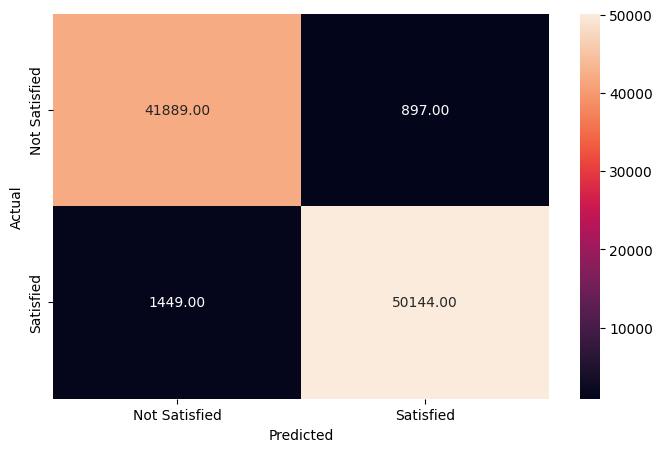

In [92]:
y_pred_ensemble_final = ensemble_final.predict(X)
metrics_score(y, y_pred_ensemble_final)

In [93]:
ensemble_final_predictions = ensemble_final.predict(test_data)

submission_ensemble_final = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': ensemble_final_predictions
})

print(submission_ensemble_final['Overall_Experience'].value_counts())

submission_ensemble_final.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_ensemble_final.csv", index=False)
print("Final ensemble submission saved!")

Overall_Experience
1    19222
0    16380
Name: count, dtype: int64
Final ensemble submission saved!


In [94]:
catboost_tuned2 = CatBoostClassifier(
    random_state=7,
    verbose=0
)

parameters = {
    'iterations': [500, 700, 1000],
    'depth': [8, 10],
    'learning_rate': [0.05, 0.1]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_cat2 = GridSearchCV(catboost_tuned2, parameters, scoring=scorer, cv=5)
grid_obj_cat2.fit(X, y)

catboost_tuned2 = grid_obj_cat2.best_estimator_
print("Best parameters:", grid_obj_cat2.best_params_)

KeyboardInterrupt: 

In [95]:
catboost_tuned2 = CatBoostClassifier(
    random_state=7,
    verbose=0
)

parameters = {
    'iterations': [500, 700],
    'depth': [8, 10],
    'learning_rate': [0.1]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_cat2 = GridSearchCV(catboost_tuned2, parameters, scoring=scorer, cv=5)
grid_obj_cat2.fit(X, y)

catboost_tuned2 = grid_obj_cat2.best_estimator_
print("Best parameters:", grid_obj_cat2.best_params_)

Best parameters: {'depth': 8, 'iterations': 700, 'learning_rate': 0.1}


In [96]:
catboost_tuned2.fit(X, y)

CatBoostClassifier(depth=8, iterations=700, learning_rate=0.1, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     42786
           1       0.99      0.98      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



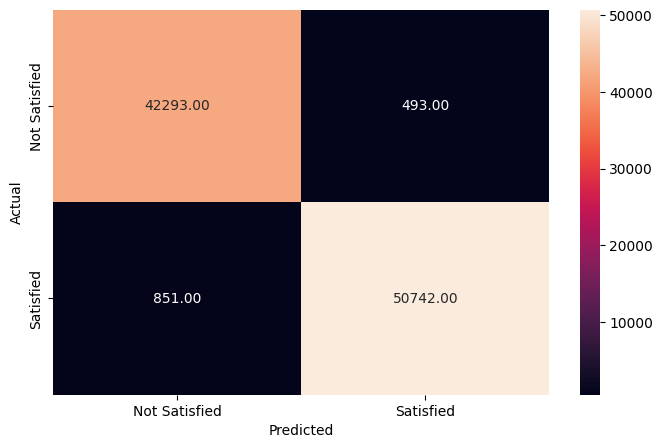

In [97]:
y_pred_catboost2 = catboost_tuned2.predict(X)
metrics_score(y, y_pred_catboost2)

In [98]:
catboost2_predictions = catboost_tuned2.predict(test_data)

submission_catboost2 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost2_predictions
})

print(submission_catboost2['Overall_Experience'].value_counts())

submission_catboost2.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost2.csv", index=False)
print("CatBoost round 2 submission saved!")

Overall_Experience
1    19239
0    16363
Name: count, dtype: int64
CatBoost round 2 submission saved!


In [99]:
catboost_tuned3 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=1000,
    learning_rate=0.1
)
catboost_tuned3.fit(X, y)

CatBoostClassifier(depth=8, iterations=1000, learning_rate=0.1, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42786
           1       0.99      0.99      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



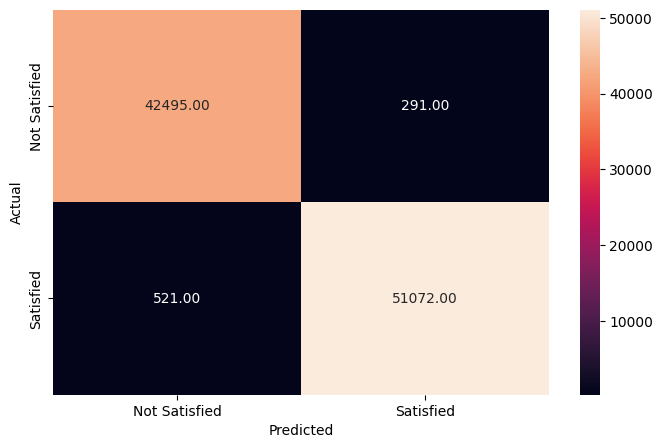

In [100]:
y_pred_catboost3 = catboost_tuned3.predict(X)
metrics_score(y, y_pred_catboost3)

In [101]:
catboost3_predictions = catboost_tuned3.predict(test_data)

submission_catboost3 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost3_predictions
})

print(submission_catboost3['Overall_Experience'].value_counts())

submission_catboost3.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost3.csv", index=False)
print("CatBoost round 3 submission saved!")

Overall_Experience
1    19252
0    16350
Name: count, dtype: int64
CatBoost round 3 submission saved!


# Feature Engineering

In [102]:
# Feature engineering - create interaction features
survey_cols = ['Seat_Comfort', 'Arrival_Time_Convenient', 'Catering',
               'Platform_Location', 'Onboard_Wifi_Service', 'Onboard_Entertainment',
               'Online_Support', 'Ease_of_Online_Booking', 'Onboard_Service',
               'Legroom', 'Baggage_Handling', 'CheckIn_Service',
               'Cleanliness', 'Online_Boarding']

# Average of all survey ratings
X['Service_Score'] = X[survey_cols].mean(axis=1)
test_data['Service_Score'] = test_data[survey_cols].mean(axis=1)

# Top 3 most important features combined
X['Entertainment_x_Comfort'] = X['Onboard_Entertainment'] * X['Seat_Comfort']
test_data['Entertainment_x_Comfort'] = test_data['Onboard_Entertainment'] * test_data['Seat_Comfort']

# Total delay combined
X['Total_Delay'] = X['Departure_Delay_in_Mins'] + X['Arrival_Delay_in_Mins']
test_data['Total_Delay'] = test_data['Departure_Delay_in_Mins'] + test_data['Arrival_Delay_in_Mins']

# Online experience score
X['Online_Score'] = X['Ease_of_Online_Booking'] + X['Online_Support'] + X['Online_Boarding']
test_data['Online_Score'] = test_data['Ease_of_Online_Booking'] + test_data['Online_Support'] + test_data['Online_Boarding']

print("New shape of X:", X.shape)
print("New shape of test_data:", test_data.shape)

New shape of X: (94379, 27)
New shape of test_data: (35602, 27)


In [103]:
catboost_fe = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=700,
    learning_rate=0.1
)
catboost_fe.fit(X, y)

CatBoostClassifier(depth=8, iterations=700, learning_rate=0.1, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     42786
           1       0.99      0.98      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



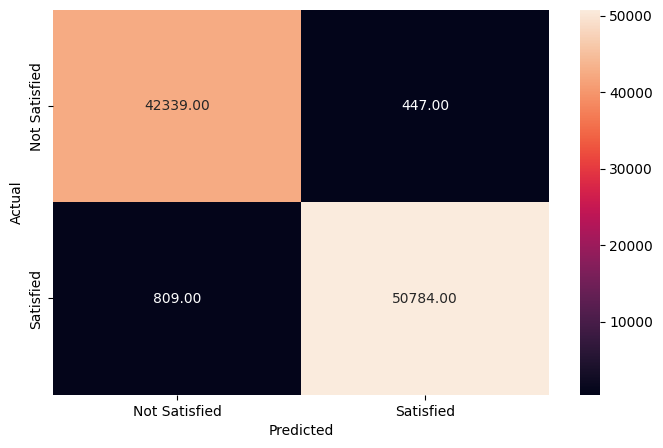

In [104]:
y_pred_catboost_fe = catboost_fe.predict(X)
metrics_score(y, y_pred_catboost_fe)

In [105]:
catboost_fe_predictions = catboost_fe.predict(test_data)

submission_catboost_fe = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost_fe_predictions
})

print(submission_catboost_fe['Overall_Experience'].value_counts())

submission_catboost_fe.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost_fe.csv", index=False)
print("CatBoost Feature Engineering submission saved!")

Overall_Experience
1    19277
0    16325
Name: count, dtype: int64
CatBoost Feature Engineering submission saved!


In [107]:
# Remove engineered features - go back to original 23 features
X = X.drop(columns=['Service_Score', 'Entertainment_x_Comfort', 'Total_Delay', 'Online_Score'])
test_data = test_data.drop(columns=['Service_Score', 'Entertainment_x_Comfort', 'Total_Delay', 'Online_Score'])

print("Shape of X:", X.shape)
print("Shape of test_data:", test_data.shape)

Shape of X: (94379, 23)
Shape of test_data: (35602, 23)


# Catboost Fine tuning

In [108]:
catboost_tuned4 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=2000,
    learning_rate=0.05
)
catboost_tuned4.fit(X, y)

CatBoostClassifier(depth=8, iterations=2000, learning_rate=0.05, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42786
           1       0.99      0.99      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



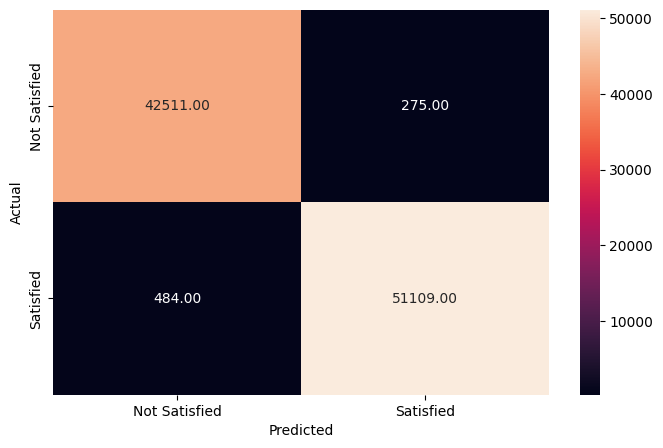

In [109]:
y_pred_catboost4 = catboost_tuned4.predict(X)
metrics_score(y, y_pred_catboost4)

In [110]:
catboost4_predictions = catboost_tuned4.predict(test_data)

submission_catboost4 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost4_predictions
})

print(submission_catboost4['Overall_Experience'].value_counts())

submission_catboost4.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost4.csv", index=False)
print("CatBoost round 4 submission saved!")

Overall_Experience
1    19237
0    16365
Name: count, dtype: int64
CatBoost round 4 submission saved!


In [111]:
catboost_tuned5 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=3000,
    learning_rate=0.03
)
catboost_tuned5.fit(X, y)

CatBoostClassifier(depth=8, iterations=3000, learning_rate=0.03, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42786
           1       0.99      0.99      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



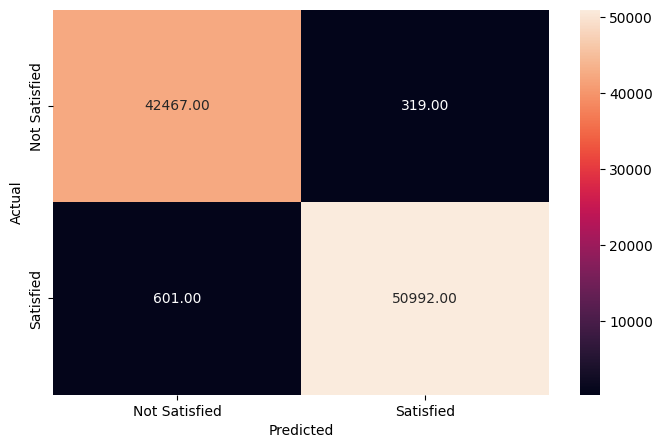

In [112]:
y_pred_catboost5 = catboost_tuned5.predict(X)
metrics_score(y, y_pred_catboost5)

In [113]:
catboost5_predictions = catboost_tuned5.predict(test_data)

submission_catboost5 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost5_predictions
})

print(submission_catboost5['Overall_Experience'].value_counts())

submission_catboost5.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost5.csv", index=False)
print("CatBoost round 5 submission saved!")

Overall_Experience
1    19243
0    16359
Name: count, dtype: int64
CatBoost round 5 submission saved!


In [115]:
catboost_tuned6 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=5000,
    learning_rate=0.01
)
catboost_tuned6.fit(X, y)

CatBoostClassifier(depth=8, iterations=5000, learning_rate=0.01, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     42786
           1       0.99      0.98      0.98     51593

    accuracy                           0.98     94379
   macro avg       0.98      0.98      0.98     94379
weighted avg       0.98      0.98      0.98     94379



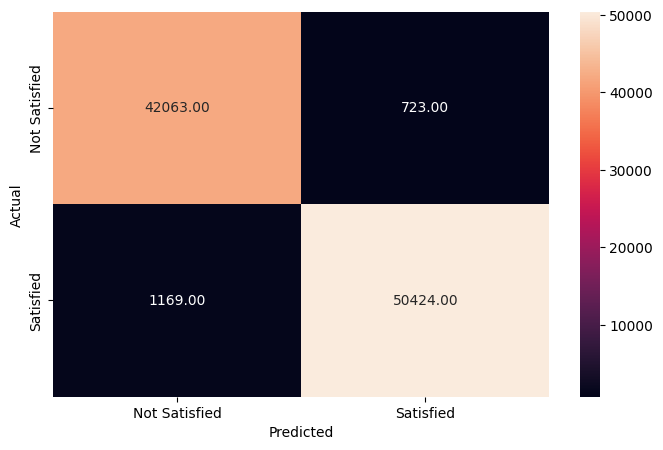

In [116]:
y_pred_catboost6 = catboost_tuned6.predict(X)
metrics_score(y, y_pred_catboost6)

In [117]:
catboost6_predictions = catboost_tuned6.predict(test_data)

submission_catboost6 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost6_predictions
})

print(submission_catboost6['Overall_Experience'].value_counts())

submission_catboost6.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost6.csv", index=False)
print("CatBoost round 6 submission saved!")

Overall_Experience
1    19219
0    16383
Name: count, dtype: int64
CatBoost round 6 submission saved!


In [118]:
catboost_tuned7 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=10000,
    learning_rate=0.01
)
catboost_tuned7.fit(X, y)

CatBoostClassifier(depth=8, iterations=10000, learning_rate=0.01, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42786
           1       0.99      0.99      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



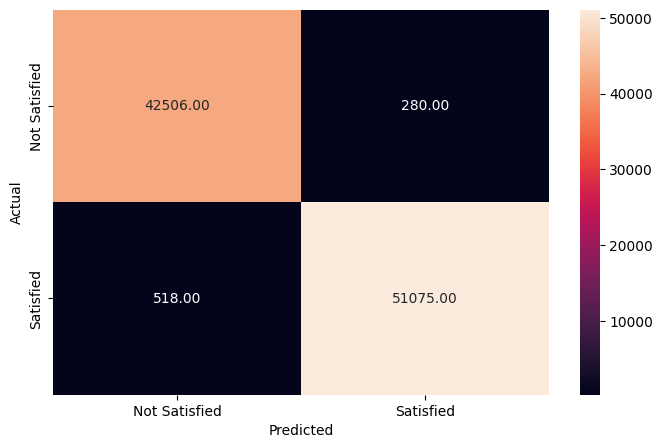

In [119]:
y_pred_catboost7 = catboost_tuned7.predict(X)
metrics_score(y, y_pred_catboost7)

In [120]:
catboost7_predictions = catboost_tuned7.predict(test_data)

submission_catboost7 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost7_predictions
})

print(submission_catboost7['Overall_Experience'].value_counts())

submission_catboost7.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost7.csv", index=False)
print("CatBoost round 7 submission saved!")

Overall_Experience
1    19225
0    16377
Name: count, dtype: int64
CatBoost round 7 submission saved!


In [121]:
catboost_tuned8 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=15000,
    learning_rate=0.01
)
catboost_tuned8.fit(X, y)

CatBoostClassifier(depth=8, iterations=15000, learning_rate=0.01, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     42786
           1       1.00      1.00      1.00     51593

    accuracy                           1.00     94379
   macro avg       1.00      1.00      1.00     94379
weighted avg       1.00      1.00      1.00     94379



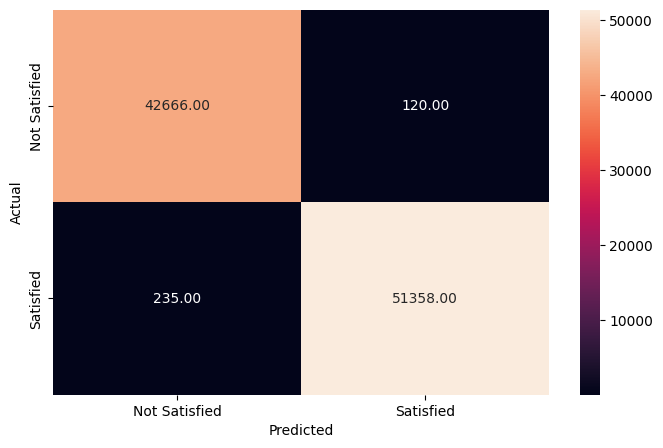

In [122]:
y_pred_catboost8 = catboost_tuned8.predict(X)
metrics_score(y, y_pred_catboost8)

In [123]:
catboost8_predictions = catboost_tuned8.predict(test_data)

submission_catboost8 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost8_predictions
})

print(submission_catboost8['Overall_Experience'].value_counts())

submission_catboost8.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost8.csv", index=False)
print("CatBoost round 8 submission saved!")

Overall_Experience
1    19219
0    16383
Name: count, dtype: int64
CatBoost round 8 submission saved!


In [124]:
catboost_tuned9 = CatBoostClassifier(
    random_state=7,
    verbose=0,
    depth=8,
    iterations=12000,
    learning_rate=0.01
)
catboost_tuned9.fit(X, y)

CatBoostClassifier(depth=8, iterations=12000, learning_rate=0.01, random_state=7, verbose=0)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     42786
           1       1.00      0.99      0.99     51593

    accuracy                           0.99     94379
   macro avg       0.99      0.99      0.99     94379
weighted avg       0.99      0.99      0.99     94379



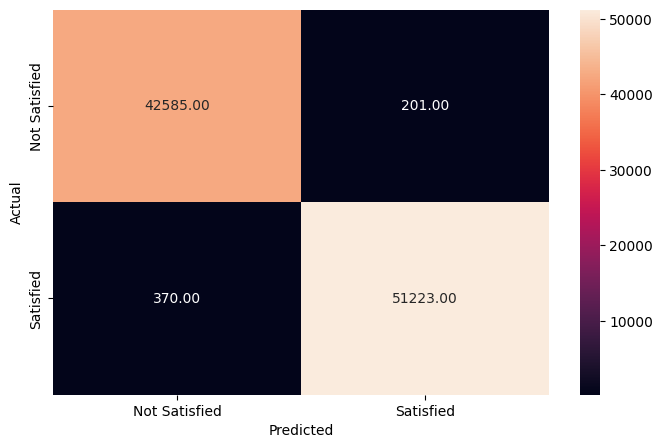

In [125]:
y_pred_catboost9 = catboost_tuned9.predict(X)
metrics_score(y, y_pred_catboost9)

In [126]:
catboost9_predictions = catboost_tuned9.predict(test_data)

submission_catboost9 = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': catboost9_predictions
})

print(submission_catboost9['Overall_Experience'].value_counts())

submission_catboost9.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_catboost9.csv", index=False)
print("CatBoost round 9 submission saved!")

Overall_Experience
1    19228
0    16374
Name: count, dtype: int64
CatBoost round 9 submission saved!


              precision    recall  f1-score   support

           0       0.94      0.96      0.95     42786
           1       0.96      0.95      0.96     51593

    accuracy                           0.95     94379
   macro avg       0.95      0.95      0.95     94379
weighted avg       0.95      0.95      0.95     94379



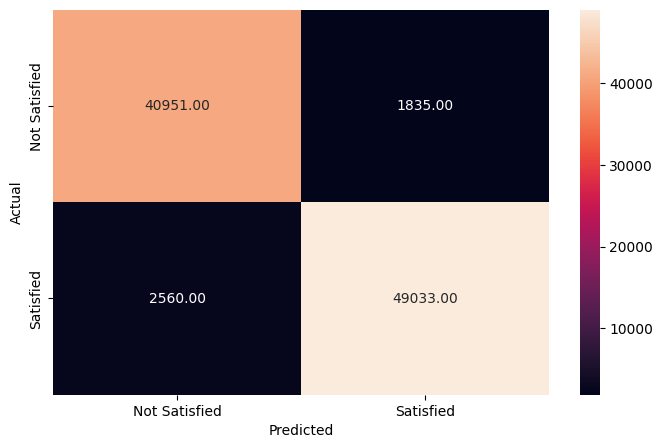

In [127]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=1)
hgb.fit(X, y)

y_pred_hgb = hgb.predict(X)
metrics_score(y, y_pred_hgb)

In [128]:
from sklearn.model_selection import GridSearchCV

hgb_tuned = HistGradientBoostingClassifier(random_state=7)

parameters = {
    'max_iter': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

scorer = metrics.make_scorer(accuracy_score)

grid_obj_hgb = GridSearchCV(hgb_tuned, parameters, scoring=scorer, cv=5)
grid_obj_hgb.fit(X, y)

hgb_tuned = grid_obj_hgb.best_estimator_
print("Best parameters:", grid_obj_hgb.best_params_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 500}


In [129]:
hgb_tuned.fit(X, y)

HistGradientBoostingClassifier(max_depth=8, max_iter=500, random_state=7)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     42786
           1       0.98      0.97      0.97     51593

    accuracy                           0.97     94379
   macro avg       0.97      0.97      0.97     94379
weighted avg       0.97      0.97      0.97     94379



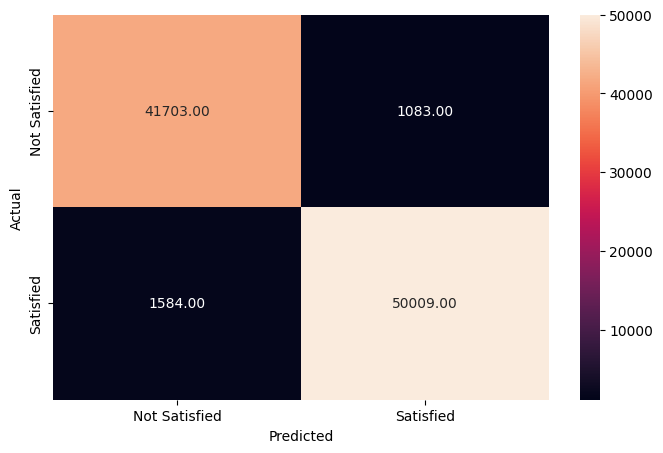

In [130]:
y_pred_hgb_tuned = hgb_tuned.predict(X)
metrics_score(y, y_pred_hgb_tuned)

In [131]:
hgb_predictions = hgb_tuned.predict(test_data)

submission_hgb = pd.DataFrame({
    'ID': sample_sub['ID'],
    'Overall_Experience': hgb_predictions
})

print(submission_hgb['Overall_Experience'].value_counts())

submission_hgb.to_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Hackathon/submission_hgb.csv", index=False)
print("HistGradientBoosting submission saved!")

Overall_Experience
1    19265
0    16337
Name: count, dtype: int64
HistGradientBoosting submission saved!


## Final Conclusions

**Models Built & Evaluated:**
- Decision Tree (baseline → tuned)
- Random Forest (baseline → tuned)
- XGBoost (baseline → 2 rounds of tuning)
- LightGBM (baseline → tuned)
- CatBoost (baseline → 9 rounds of tuning)
- HistGradientBoosting (baseline → tuned)
- Multiple ensemble combinations (XGB + LGBM, XGB + LGBM + CatBoost)

**Model Performance Summary:**
- Decision Tree tuned: 0.93 train accuracy → not submitted as final
- Random Forest tuned: 0.91 train accuracy → 0.9041 leaderboard
- XGBoost tuned round 2: 0.97 train accuracy → 0.9529 leaderboard
- LightGBM tuned: 0.97 train accuracy → 0.9537 leaderboard
- XGB + LGBM + CatBoost ensemble: 0.97 train accuracy → 0.9541 leaderboard
- CatBoost tuned round 1: 0.98 train accuracy → 0.9556 leaderboard
- CatBoost tuned round 7: 0.99 train accuracy → 0.9569 leaderboard ← best

**Why We Progressed Through Models:**
- Random Forest plateaued at 90.41% — sequential boosting models were needed
- XGBoost improved to 95.29% by correcting errors sequentially
- LightGBM matched XGBoost with a different leaf-wise approach
- CatBoost outperformed all others using ordered boosting — uniquely suited to this structured survey data
- Ensembles helped marginally but standalone tuned CatBoost proved strongest
- HistGradientBoosting was tested last but did not improve over CatBoost

**Final Model — CatBoost (Round 7):**
- Best parameters: depth=8, iterations=10,000, learning_rate=0.01
- Train accuracy: 99% — Leaderboard accuracy: 95.69%
- Key finding: lower learning rate with more iterations generalizes better — model peaked at 99% training accuracy before overfitting at 100%
- Selected because it consistently outperformed all other models and ensembles on unseen test data

**Key Drivers of Passenger Satisfaction (consistent across all models):**
- Onboard_Entertainment — dominant feature across all models
- Seat_Comfort — second most important
- Ease_of_Online_Booking — third most important
- Travel_Class, Customer_Type, and Type_Travel also meaningful
- Delay columns had minimal impact — service quality matters far more than punctuality

**Hackathon Result:**
- Final leaderboard score: 0.9569125
- Leaderboard rank: 2 out of all participants
- Total submissions: 17 vs rank 1's 35 — achieved near-equivalent accuracy in fewer attempts